# Chapter 2- Group Exercise 2 - Regression Analysis and Feature Selection
Perform regression analysis on a dataset with over 1000 data points and at least 30 features. Apply preprocessing, build models, evaluate performance, and enhance them using feature selection methods. Demonstrate creativity with additional techniques or insights.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
np.random.seed(42)

Dataset of US wildfires

Source: https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires

Data was filtered to last 2 years and converted to CSV for manageability

Feature descriptions available at the source link

In [3]:
# Load the raw wildfire dataset
df = pd.read_csv('fire_data_last_2_years.csv')
df.head()

/tmp/ipykernel_804/4146011757.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('fire_data_last_2_years.csv')


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
0,1721941,300000001,FS-1524899,FED,FS-FIRESTAT,FS,USIDNCF,Nez Perce - Clearwater National Forests,0117,Nezperce National Forest,...,A,45.340833,-116.466667,5.0,USFS,ID,Idaho,49.0,Idaho,b'\x00\x01\xad\x10\x00\x00\x1cr\xe1\xdd\xdd\x1...
1,1721942,300000002,FS-1524894,FED,FS-FIRESTAT,FS,USIDNCF,Nez Perce - Clearwater National Forests,0117,Nezperce National Forest,...,A,45.505278,-116.425556,5.0,USFS,ID,Idaho,49.0,Idaho,"b'\x00\x01\xad\x10\x00\x00,5cM<\x1b]\xc0p?:\xf..."
2,1721943,300000003,FS-1524891,FED,FS-FIRESTAT,FS,USIDNCF,Nez Perce - Clearwater National Forests,0117,Nezperce National Forest,...,A,45.908056,-115.767778,5.0,USFS,ID,Idaho,49.0,Idaho,b'\x00\x01\xad\x10\x00\x00\x80\xeciE#\xf1\\\xc...
3,1721944,300000004,FS-1524900,FED,FS-FIRESTAT,FS,USIDNCF,Nez Perce - Clearwater National Forests,0117,Nezperce National Forest,...,A,45.840000,-115.966389,5.0,USFS,ID,Idaho,49.0,Idaho,b'\x00\x01\xad\x10\x00\x00 q\xc9P\xd9\xfd\\\xc...
4,1721945,300000005,FS-1522737,FED,FS-FIRESTAT,FS,USIDNCF,Nez Perce - Clearwater National Forests,0117,Nezperce National Forest,...,A,45.598333,-115.449167,5.0,USFS,ID,Idaho,49.0,Idaho,b'\x00\x01\xad\x10\x00\x00\x98\x86\x8f%\xbf\xd...


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
# Define target and features
target = 'FIRE_SIZE'
X = df.drop(columns=[target])
y = df[target]

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (113795, 38)
Test set: (28449, 38)


The dataset is split 80/20 into training (78,294 rows) and test (19,574 rows) sets before any scaling, encoding, or feature engineering.

This ensures all transformations are fitted on the training set only and applied to the test set, preventing data leakage, where information from the test set influences the model during training.

This simulates how the model would perform on genuinely unseen data.

## Preprocessing
- Handle missing values and outliers.
- Scale features using standardization or normalization.
- Perform feature selection.

## Missing Values

In [6]:
# Check dataset features and identify missing values
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113795 entries, 40479 to 121958
Data columns (total 38 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   OBJECTID                    113795 non-null  int64  
 1   FOD_ID                      113795 non-null  int64  
 2   FPA_ID                      113795 non-null  object 
 3   SOURCE_SYSTEM_TYPE          113795 non-null  object 
 4   SOURCE_SYSTEM               113795 non-null  object 
 5   NWCG_REPORTING_AGENCY       113795 non-null  object 
 6   NWCG_REPORTING_UNIT_ID      113795 non-null  object 
 7   NWCG_REPORTING_UNIT_NAME    113795 non-null  object 
 8   SOURCE_REPORTING_UNIT       113795 non-null  object 
 9   SOURCE_REPORTING_UNIT_NAME  113795 non-null  object 
 10  LOCAL_FIRE_REPORT_ID        20513 non-null   float64
 11  LOCAL_INCIDENT_ID           99437 non-null   object 
 12  FIRE_CODE                   24450 non-null   object 
 13  FIRE_NAME      

In [7]:
# Missing percentages (divide by total rows)
missing_pct = (X_train.isnull().sum() / len(X_train)) * 100
print(f"\nColumns with Missing Values: {len(missing_pct[missing_pct > 0])}")
missing_pct[missing_pct > 0].sort_values(ascending=False)


Columns with Missing Values: 16


COMPLEX_NAME               99.579946
MTBS_ID                    99.418252
MTBS_FIRE_NAME             99.418252
ICS_209_INCIDENT_NUMBER    98.054396
ICS_209_NAME               98.054396
LOCAL_FIRE_REPORT_ID       81.973725
FIRE_CODE                  78.513994
CONT_TIME                  28.087350
FIRE_NAME                  22.243508
DISCOVERY_TIME             20.763654
CONT_DOY                   19.395404
CONT_DATE                  19.395404
LOCAL_INCIDENT_ID          12.617426
COUNTY                     12.299310
FIPS_CODE                  12.299310
FIPS_NAME                  12.299310
dtype: float64

We will first remove columns that are not useful for analysis like:
- ID columns (OBJECTID, FOD_ID, etc.)
- Columns with >70% missing data
- Redundant columns

In [8]:
# Removing IDs and redundant columns
id_and_redundant_columns = [
    # Identifiers (no analytical value)
    'OBJECTID',
    'FPA_ID',
    'LOCAL_INCIDENT_ID',
    'LOCAL_FIRE_REPORT_ID',

    # Redundant
    'SOURCE_REPORTING_UNIT',  # Redundant with NWCG_REPORTING_UNIT_ID
    'SOURCE_REPORTING_UNIT_NAME',  # Redundant with NWCG_REPORTING_UNIT_NAME
    'STAT_CAUSE_CODE',  # Redundant with STAT_CAUSE_DESCR
    'OWNER_CODE',  # Redundant with OWNER_DESCR

    # Geometric/shape data (not useful for basic tabular analysis)
    'Shape'
]

X_train = X_train.drop(columns=id_and_redundant_columns)
X_test = X_test.drop(columns=id_and_redundant_columns)
print(f"Remaining columns: {X_train.shape[1]}")

Remaining columns: 29


In [9]:
# We will drop all columns where more than 70% of the column value is missing
# They too sparse for reliable imputation
high_missing_columns = [
    'FIRE_CODE',  # 78% missing
    'ICS_209_INCIDENT_NUMBER',  # 98% missing
    'ICS_209_NAME',  # 98% missing
    'MTBS_ID',  # 99% missing
    'MTBS_FIRE_NAME',  # 99% missing
    'COMPLEX_NAME'  # 99% missing
]

X_train = X_train.drop(columns=high_missing_columns)
X_test = X_test.drop(columns=high_missing_columns)
print(f"Remaining columns: {X_train.shape[1]}")

Remaining columns: 23


- FOD_ID is retained as a unique identifier as it allows each record to be traced back to the original data source for debugging or analysis.

- It will not be used as a model feature and is kept strictly for record-keeping purposes.

In [10]:
# Recalculate missing percentages after column removal
missing_pct = (X_train.isnull().sum() / len(X_train)) * 100
missing_pct[missing_pct > 0].sort_values(ascending=False)

CONT_TIME         28.087350
FIRE_NAME         22.243508
DISCOVERY_TIME    20.763654
CONT_DATE         19.395404
CONT_DOY          19.395404
COUNTY            12.299310
FIPS_CODE         12.299310
FIPS_NAME         12.299310
dtype: float64

Now we investigate the why behind missing values to choose appropriate imputation strategies.

#### Feature 1: CONT_DATE (Containment Date) / CONT_TIME (Containment Time) / CONT_DOY (Containment Day of Year)

In [11]:
# Check if CONT_DATE and CONT_DOY are always missing in the same records
print("\nCONT_DATE missing:", X_train['CONT_DATE'].isna().sum())
print("CONT_DOY missing:", X_train['CONT_DOY'].isna().sum())

# Check if they're missing in the exact same rows
both_missing = X_train['CONT_DATE'].isna() & X_train['CONT_DOY'].isna()
print("Both missing together:", both_missing.sum())

# Check if one is missing without the other
only_date_missing = X_train['CONT_DATE'].isna() & X_train['CONT_DOY'].notna()
only_doy_missing = X_train['CONT_DATE'].notna() & X_train['CONT_DOY'].isna()
print("Only CONT_DATE missing:", only_date_missing.sum())
print("Only CONT_DOY missing:", only_doy_missing.sum())


CONT_DATE missing: 22071
CONT_DOY missing: 22071
Both missing together: 22071
Only CONT_DATE missing: 0
Only CONT_DOY missing: 0


In [12]:
# How many CONT_DATE, CONT_DOY, and CONT_TIME are missing?
print("\nNumber of missing values of:")
print("CONT_DATE:", X_train['CONT_DATE'].isna().sum())
print("CONT_DOY:", X_train['CONT_DOY'].isna().sum())
print("CONT_TIME:", X_train['CONT_TIME'].isna().sum())

# Check if they're missing in the same rows
missing_all = X_train[X_train['CONT_DATE'].isna() &
                      X_train['CONT_DOY'].isna() &
                      X_train['CONT_TIME'].isna()]
print(f"\nIn {len(missing_all)} rows ALL three features are missing")
print(f"Percentage of training data: {len(missing_all) / len(X_train) * 100:.2f}%")


Number of missing values of:
CONT_DATE: 22071
CONT_DOY: 22071
CONT_TIME: 31962

In 22071 rows ALL three features are missing
Percentage of training data: 19.40%


When CONT_DATE and CONT_DOY are missing, CONT_TIME is always missing too. However, there are 9,891 cases where we have a containment date and day of year but no containment time.


Distribution in Training Set:
count    81833.000000
mean       947.454462
std        240.310149
min          0.000000
25%        822.000000
50%        961.000000
75%       1095.000000
max       1439.000000
Name: CONT_TIME_MINUTES, dtype: float64

Skewness: -0.9053


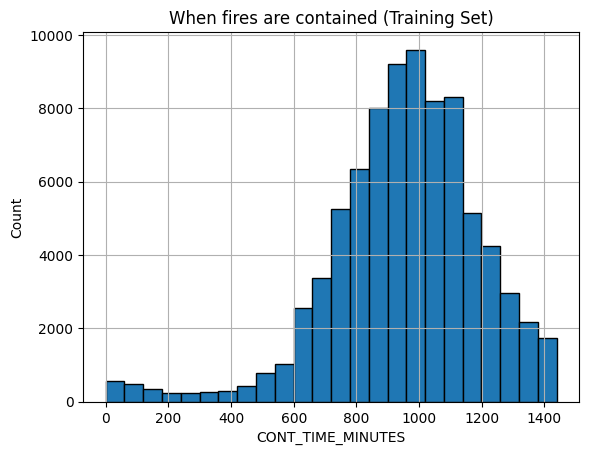

In [13]:
# Convert time to minutes for BOTH train and test
X_train['CONT_TIME_MINUTES'] = (X_train['CONT_TIME'] // 100) * 60 + (X_train['CONT_TIME'] % 100)
X_test['CONT_TIME_MINUTES'] = (X_test['CONT_TIME'] // 100) * 60 + (X_test['CONT_TIME'] % 100)

print("\nDistribution in Training Set:")
print(X_train['CONT_TIME_MINUTES'].describe())

# Check skewness
print(f"\nSkewness: {X_train['CONT_TIME_MINUTES'].skew():.4f}")

# Histogram with 24 bins (24 hours)
import matplotlib.pyplot as plt

X_train['CONT_TIME_MINUTES'].hist(bins=24, edgecolor='black')
plt.xlabel('CONT_TIME_MINUTES')
plt.ylabel('Count')
plt.title('When fires are contained (Training Set)')
plt.show()

Records missing CONT_DATE and CONT_DOY will be removed because these fields share a 1:1 relationship and cannot be reconstructed without temporal modelling (out of scope). For the remaining ~10,000 rows where date information is present but CONT_TIME is missing, values will be imputed using Gaussian noise via a NumPy random number generator. This method is appropriate as the existing CONT_TIME data follows an approximately normal distribution.

In [14]:
# Remove rows where the containment date is missing
original_train_rows = len(X_train)
train_mask = X_train['CONT_DATE'].notna() & X_train['CONT_DOY'].notna()
X_train = X_train[train_mask]
y_train = y_train[train_mask]

original_test_rows = len(X_test)
test_mask = X_test['CONT_DATE'].notna() & X_test['CONT_DOY'].notna()
X_test = X_test[test_mask]
y_test = y_test[test_mask]

print(f"Dropped {original_train_rows - len(X_train)} rows from training set due to missing date information.")
print(f"Dropped {original_test_rows - len(X_test)} rows from test set due to missing date information.")

# Impute remaining missing minutes using Gaussian noise
train_mu = X_train['CONT_TIME_MINUTES'].mean()
train_sigma = X_train['CONT_TIME_MINUTES'].std()

# Apply imputation to Training Set
train_missing = X_train['CONT_TIME_MINUTES'].isna()
X_train.loc[train_missing, 'CONT_TIME_MINUTES'] = np.clip(
    np.random.normal(train_mu, train_sigma, train_missing.sum()), 0, 1439
)

# Apply imputation to Test Set using Training Set statistics to avoid data leakage
test_missing = X_test['CONT_TIME_MINUTES'].isna()
X_test.loc[test_missing, 'CONT_TIME_MINUTES'] = np.clip(
    np.random.normal(train_mu, train_sigma, test_missing.sum()), 0, 1439
)

# Drop the original CONT_TIME column as it is no longer needed and contains NaNs
X_train = X_train.drop(columns=['CONT_TIME'])
X_test = X_test.drop(columns=['CONT_TIME'])

print(f"Imputed {train_missing.sum()} time values in training set.")
print(f"Imputed {test_missing.sum()} time values in test set.")
print(f"Final training shape: {X_train.shape}")

Dropped 22071 rows from training set due to missing date information.
Dropped 5569 rows from test set due to missing date information.
Imputed 9891 time values in training set.
Imputed 2436 time values in test set.
Final training shape: (91724, 23)


As a next step we will deal the feature FIRE_NAME

#### Feature 2: FIRE_NAME

In [15]:
# Check FIRE_NAME uniqueness
print(f"Total Entries: {len(X_train)}")
print(f"Unique fire names: {X_train['FIRE_NAME'].nunique()}")
print(
    f"Missing values: {X_train['FIRE_NAME'].isna().sum()} ({X_train['FIRE_NAME'].isna().sum() / len(X_train) * 100:.2f}%)")
print(f"Ratio of unique names to total entries: {X_train['FIRE_NAME'].nunique() / len(X_train):.5f}")

print("\nTop 10 fire names:")
print(X_train['FIRE_NAME'].value_counts().head(10))

# Check STAT_CAUSE_DESCR uniqueness for comparison
print(f"Total Entries: {len(X_train)}")
print(f"Unique cause descriptions: {X_train['STAT_CAUSE_DESCR'].nunique()}")
print(f"Missing values: {X_train['STAT_CAUSE_DESCR'].isna().sum()}")
print(f"Ratio of unique causes to total entries: {X_train['STAT_CAUSE_DESCR'].nunique() / len(X_train):.5f}")

print("\nTop 10 fire causes:")
print(X_train['STAT_CAUSE_DESCR'].value_counts().head(10))

Total Entries: 91724
Unique fire names: 56828
Missing values: 19846 (21.64%)
Ratio of unique names to total entries: 0.61955

Top 10 fire names:
FIRE_NAME
PLYMOUTH      88
BROCKTON      69
QUINCY        63
WEYMOUTH      49
BRAINTREE     45
CREEK         42
COTTONWOOD    42
WILLOW        41
ROCK          40
DEER          37
Name: count, dtype: int64
Total Entries: 91724
Unique cause descriptions: 13
Missing values: 0
Ratio of unique causes to total entries: 0.00014

Top 10 fire causes:
STAT_CAUSE_DESCR
Debris Burning       23051
Miscellaneous        19384
Lightning            13288
Arson                 9786
Missing/Undefined     7240
Equipment Use         6025
Campfire              5538
Children              2028
Smoking               1933
Powerline             1528
Name: count, dtype: int64


The FIRE_NAME column will be removed because it contains arbitrary descriptive labels with a ~21% missingness rate and high uniqueness (62%), making it unsuitable for standardised analysis. Since STAT_CAUSE_DESCR provides formal cause categories and location data is already captured via FIPS_NAME and coordinates, the column is redundant for categorical or spatial modelling.

In [16]:
X_train = X_train.drop(columns=['FIRE_NAME'])
X_test = X_test.drop(columns=['FIRE_NAME'])

print(f"\nAfter removal:")
print(f"X_train columns: {X_train.shape[1]}")
print(f"X_test columns: {X_test.shape[1]}")


After removal:
X_train columns: 22
X_test columns: 22


Following this we will analyse DISCOVERY_TIME

#### Feature 3: DISCOVERY_TIME

Has DISCOVERY_TIME: 83638
Missing DISCOVERY_TIME: 8086
Missing percentage: 8.82%

Distribution (Training Set):
count    83638.000000
mean       906.376551
std        229.090979
min          0.000000
25%        784.000000
50%        907.000000
75%       1045.000000
max       1439.000000
Name: DISCOVERY_TIME_MINUTES, dtype: float64
Skewness of DISCOVERY_TIME_MINUTES: -0.6466


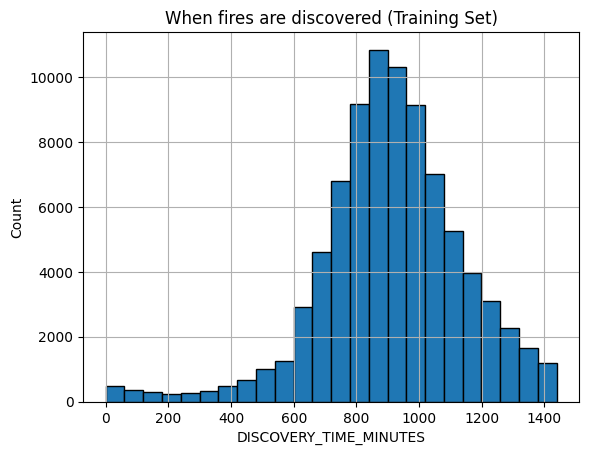

In [17]:
# Convertion of time to minutes
X_train['DISCOVERY_TIME_MINUTES'] = (X_train['DISCOVERY_TIME'] // 100) * 60 + (X_train['DISCOVERY_TIME'] % 100)
X_test['DISCOVERY_TIME_MINUTES'] = (X_test['DISCOVERY_TIME'] // 100) * 60 + (X_test['DISCOVERY_TIME'] % 100)

# Check missing count
print(f"Has DISCOVERY_TIME: {X_train['DISCOVERY_TIME_MINUTES'].notna().sum()}")
print(f"Missing DISCOVERY_TIME: {X_train['DISCOVERY_TIME_MINUTES'].isna().sum()}")
print(f"Missing percentage: {X_train['DISCOVERY_TIME_MINUTES'].isna().sum() / len(X_train) * 100:.2f}%")

print("\nDistribution (Training Set):")
print(X_train['DISCOVERY_TIME_MINUTES'].describe())

# Skewness of discovery time
skewness = X_train['DISCOVERY_TIME_MINUTES'].skew()
print(f"Skewness of DISCOVERY_TIME_MINUTES: {skewness:.4f}")

# Histogram with 24 bins (24 hours in military time)
X_train['DISCOVERY_TIME_MINUTES'].hist(bins=24, edgecolor='black')
plt.xlabel('DISCOVERY_TIME_MINUTES')
plt.ylabel('Count')
plt.title('When fires are discovered (Training Set)')
plt.show()

The CONT_TIME variable exhibits an approximately normal distribution centered at 907 minutes (roughly 3:00 PM) with a skewness of roughly -0.64. Given the low rate of missingness (~8%), missing values will be imputed using Gaussian noise with a standard deviation of 229 minutes. This approach is justified because sampling from the existing distribution maintains realistic variance and preserves the statistical integrity of the time-of-day data.

In [18]:
# Calculate Gaussian parameters from the training set for imputation
disc_mu = X_train['DISCOVERY_TIME_MINUTES'].mean()
disc_sigma = X_train['DISCOVERY_TIME_MINUTES'].std()

# Impute missing values in the Training Set
missing_disc_train = X_train['DISCOVERY_TIME_MINUTES'].isna()
X_train.loc[missing_disc_train, 'DISCOVERY_TIME_MINUTES'] = np.clip(
    np.random.normal(disc_mu, disc_sigma, missing_disc_train.sum()), 0, 1439
)

# Impute missing values in the Test Set using Training statistics
missing_disc_test = X_test['DISCOVERY_TIME_MINUTES'].isna()
X_test.loc[missing_disc_test, 'DISCOVERY_TIME_MINUTES'] = np.clip(
    np.random.normal(disc_mu, disc_sigma, missing_disc_test.sum()), 0, 1439
)

# Drop discovery time
X_train = X_train.drop(columns=['DISCOVERY_TIME'])
X_test = X_test.drop(columns=['DISCOVERY_TIME'])

print(f"Filled {missing_disc_train.sum()} missing values in Training set")
print(f"Filled {missing_disc_test.sum()} missing values in Test set")

Filled 8086 missing values in Training set
Filled 1972 missing values in Test set


At last we check FIPS_CODE/FIPS_NAME

#### Feature 4: FIPS_CODE / FIPS_NAME

In [19]:
# Missing count
print(
    f"Missing FIPS_CODE: {X_train['FIPS_CODE'].isna().sum()} ({X_train['FIPS_CODE'].isna().sum() / len(X_train) * 100:.2f}%)")
print(
    f"Missing FIPS_NAME: {X_train['FIPS_NAME'].isna().sum()} ({X_train['FIPS_NAME'].isna().sum() / len(X_train) * 100:.2f}%)")

# Are both missing on the same row
both_missing = X_train['FIPS_CODE'].isna() & X_train['FIPS_NAME'].isna()
print(f"Both missing together: {both_missing.sum()} ({both_missing.sum() / len(X_train) * 100:.2f}%)")

# Check if one is missing without the other
only_code_missing = X_train['FIPS_CODE'].isna() & X_train['FIPS_NAME'].notna()
only_name_missing = X_train['FIPS_CODE'].notna() & X_train['FIPS_NAME'].isna()
print(f"Only FIPS_CODE missing: {only_code_missing.sum()}")
print(f"Only FIPS_NAME missing: {only_name_missing.sum()}")

Missing FIPS_CODE: 13410 (14.62%)
Missing FIPS_NAME: 13410 (14.62%)
Both missing together: 13410 (14.62%)
Only FIPS_CODE missing: 0
Only FIPS_NAME missing: 0


In [20]:
# Drop rows with missing FIPS
original_train_rows = len(X_train)
train_mask = X_train['FIPS_CODE'].notna() & X_train['FIPS_NAME'].notna()
X_train = X_train[train_mask]
y_train = y_train[train_mask]

print(f"\nTraining set:")
print(f"Original rows: {original_train_rows}")
print(f"Dropped rows: {original_train_rows - len(X_train)}")
print(f"Remaining rows: {len(X_train)} ({len(X_train) / original_train_rows * 100:.2f}%)")

original_test_rows = len(X_test)
test_mask = X_test['FIPS_CODE'].notna() & X_test['FIPS_NAME'].notna()
X_test = X_test[test_mask]
y_test = y_test[test_mask]

print(f"\nTest set:")
print(f"Original rows: {original_test_rows}")
print(f"Dropped rows: {original_test_rows - len(X_test)}")
print(f"Remaining rows: {len(X_test)} ({len(X_test) / original_test_rows * 100:.2f}%)")


Training set:
Original rows: 91724
Dropped rows: 13410
Remaining rows: 78314 (85.38%)

Test set:
Original rows: 22880
Dropped rows: 3326
Remaining rows: 19554 (85.46%)


Rows missing FIPS codes will be removed because county-level location is essential for analysis, and the 15% missingness rate is too high for simple imputation. While broad location context remains available through coordinates, precise imputation would require reverse geocoding (out of scope). Dropping these records retains 97,868 observations (85% of the data), which is sufficient for a robust analysis.

In [21]:
# Check for any remaining missing values
missing_test = X_test.isnull().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing_test[missing_test > 0])
print(f"\nFinal shape: {df.shape}")

Missing values per column:
Series([], dtype: int64)

Final shape: (142244, 39)


## Handling Outliers



In [22]:
from scipy.stats import zscore

### Fire Size Outliers

In [23]:
# Examine distribution
print("FIRE_SIZE statistics:")
print(y_train.describe())

FIRE_SIZE statistics:
count     78314.000000
mean         79.760221
std        2701.836819
min           0.000100
25%           0.100000
50%           0.500000
75%           3.000000
max      312918.300000
Name: FIRE_SIZE, dtype: float64


In [24]:
#  Calculate Z-score for FIRE_SIZE
fire_size_z = pd.Series(
    zscore(y_train),
    index=y_train.index
)

# Detect outliers (|z-score| > 3)
outliers_z = fire_size_z[fire_size_z.abs() > 3]

print(f"Z-score outliers: {len(outliers_z)}")



Z-score outliers: 115


In [25]:
# IQR outlier detection

Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = y_train[(y_train < lower) | (y_train > upper)]

print("\nIQR Method:")
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Bounds: [{lower:.0f}, {upper:.0f}]")
print(f"Outliers detected: {len(outliers_iqr)} ({round(len(outliers_iqr) / len(y_train) * 100, 1)}%)")



IQR Method:
Q1=0.1, Q3=3.0, IQR=2.9
Bounds: [-4, 7]
Outliers detected: 11628 (14.8%)


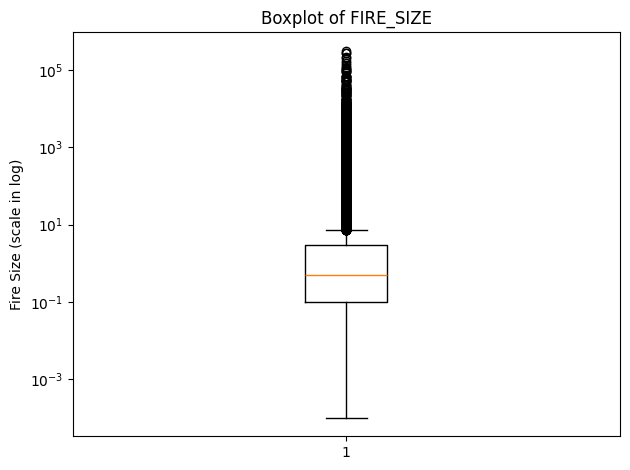

In [26]:
# Visualize outliers with boxplot
plt.boxplot(y_train, vert=True, showfliers=True)
plt.yscale('log')
plt.ylabel('Fire Size (scale in log)')
plt.title('Boxplot of FIRE_SIZE')
plt.tight_layout()
plt.show()

We will keep all outliers without removal or transformation as Fire size follows a non Gaussian distribution where extreme values are inherent to the phenomenon, not errors.

In [27]:
# Drop the temporary pandas series and variables
del fire_size_z
del outliers_z
del outliers_iqr

### Geographic Outliers

Z-score method (threshold: |z| > 3):
  Latitude outliers: 150 (0.19%)
  Longitude outliers: 74 (0.09%)
  Total geographic outliers: 150 (0.19%)

Top 10 States flagged as outliers:
STATE
AK    97
PR    51
HI     2
Name: count, dtype: int64

IQR method:
  Geographic outliers: 150 (0.19%)


/tmp/ipykernel_804/2075723923.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([X_train[lat_col], X_train[lon_col]], labels=['Latitude', 'Longitude'])


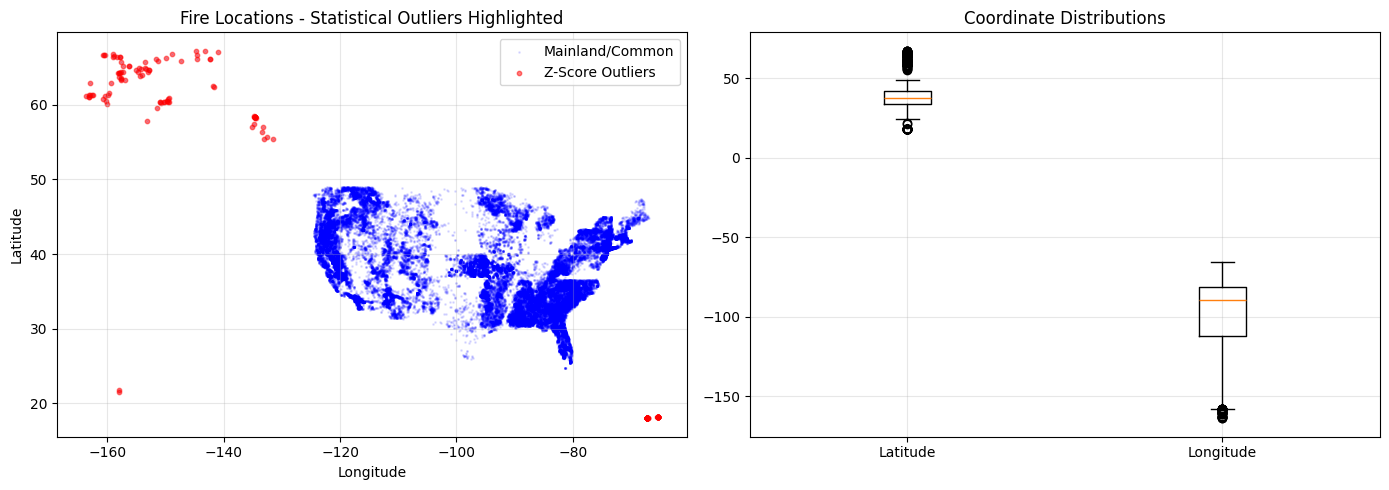

In [28]:
# Use the actual column names from your X_train
lat_col = 'LATITUDE'
lon_col = 'LONGITUDE'

# Calculate Z-scores
lat_z = zscore(X_train[lat_col])
lon_z = zscore(X_train[lon_col])

# Detect outliers (|z-score| > 3)
lat_outliers = X_train[np.abs(lat_z) > 3]
lon_outliers = X_train[np.abs(lon_z) > 3]
geo_outliers = X_train[(np.abs(lat_z) > 3) | (np.abs(lon_z) > 3)]

print(f"Z-score method (threshold: |z| > 3):")
print(f"  Latitude outliers: {len(lat_outliers)} ({len(lat_outliers) / len(X_train) * 100:.2f}%)")
print(f"  Longitude outliers: {len(lon_outliers)} ({len(lon_outliers) / len(X_train) * 100:.2f}%)")
print(f"  Total geographic outliers: {len(geo_outliers)} ({len(geo_outliers) / len(X_train) * 100:.2f}%)")

# Show which states these are
if len(geo_outliers) > 0:
    print(f"\nTop 10 States flagged as outliers:")
    print(geo_outliers['STATE'].value_counts().head(10))

# 3. IQR method for comparison
Q1_lat, Q3_lat = X_train[lat_col].quantile([0.25, 0.75])
IQR_lat = Q3_lat - Q1_lat

Q1_lon, Q3_lon = X_train[lon_col].quantile([0.25, 0.75])
IQR_lon = Q3_lon - Q1_lon

iqr_outliers = X_train[
    (X_train[lat_col] < Q1_lat - 1.5 * IQR_lat) | (X_train[lat_col] > Q3_lat + 1.5 * IQR_lat) |
    (X_train[lon_col] < Q1_lon - 1.5 * IQR_lon) | (X_train[lon_col] > Q3_lon + 1.5 * IQR_lon)
    ]

print(f"\nIQR method:")
print(f"  Geographic outliers: {len(iqr_outliers)} ({len(iqr_outliers) / len(X_train) * 100:.2f}%)")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Map view
ax1.scatter(X_train[lon_col], X_train[lat_col], alpha=0.1, s=1, c='blue', label='Mainland/Common')
if len(geo_outliers) > 0:
    ax1.scatter(geo_outliers[lon_col], geo_outliers[lat_col],
                alpha=0.5, s=10, c='red', label='Z-Score Outliers')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Fire Locations - Statistical Outliers Highlighted')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Boxplots
ax2.boxplot([X_train[lat_col], X_train[lon_col]], labels=['Latitude', 'Longitude'])
ax2.set_title('Coordinate Distributions')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
del lat_z
del lon_z
del lat_outliers
del lon_outliers
del geo_outliers

While Alabama, Puerto Rico, and Hawaii are distant from the geographic mean, they provide essential wildfire data for the Southeast and island territories. Unlike extreme fire-size outliers, these spatial outliers reflect the actual geographic breadth of the dataset. Retaining them ensures the model remains representative and capable of predicting fires across diverse US regions.

### CONT_TIME_MINUTES / DISCOVERY_TIME_MINUTES

In [30]:
# Define the columns we want to check
cols_to_check = ['CONT_TIME_MINUTES', 'DISCOVERY_TIME_MINUTES']

outlier_counts = {}

for col in cols_to_check:
    # Calculate Z-scores
    z_scores = np.abs(stats.zscore(X_train[col]))

    # Count where absolute Z-score is greater than 3
    count = (z_scores > 3).sum()
    outlier_counts[col] = count

print("Outlier Detection Results (|z| > 3):")
for col, count in outlier_counts.items():
    percentage = (count / len(X_train)) * 100
    print(f"{col:22} | Count: {count:<5} | ({percentage:.2f}%)")

Outlier Detection Results (|z| > 3):
CONT_TIME_MINUTES      | Count: 1248  | (1.59%)
DISCOVERY_TIME_MINUTES | Count: 1020  | (1.30%)


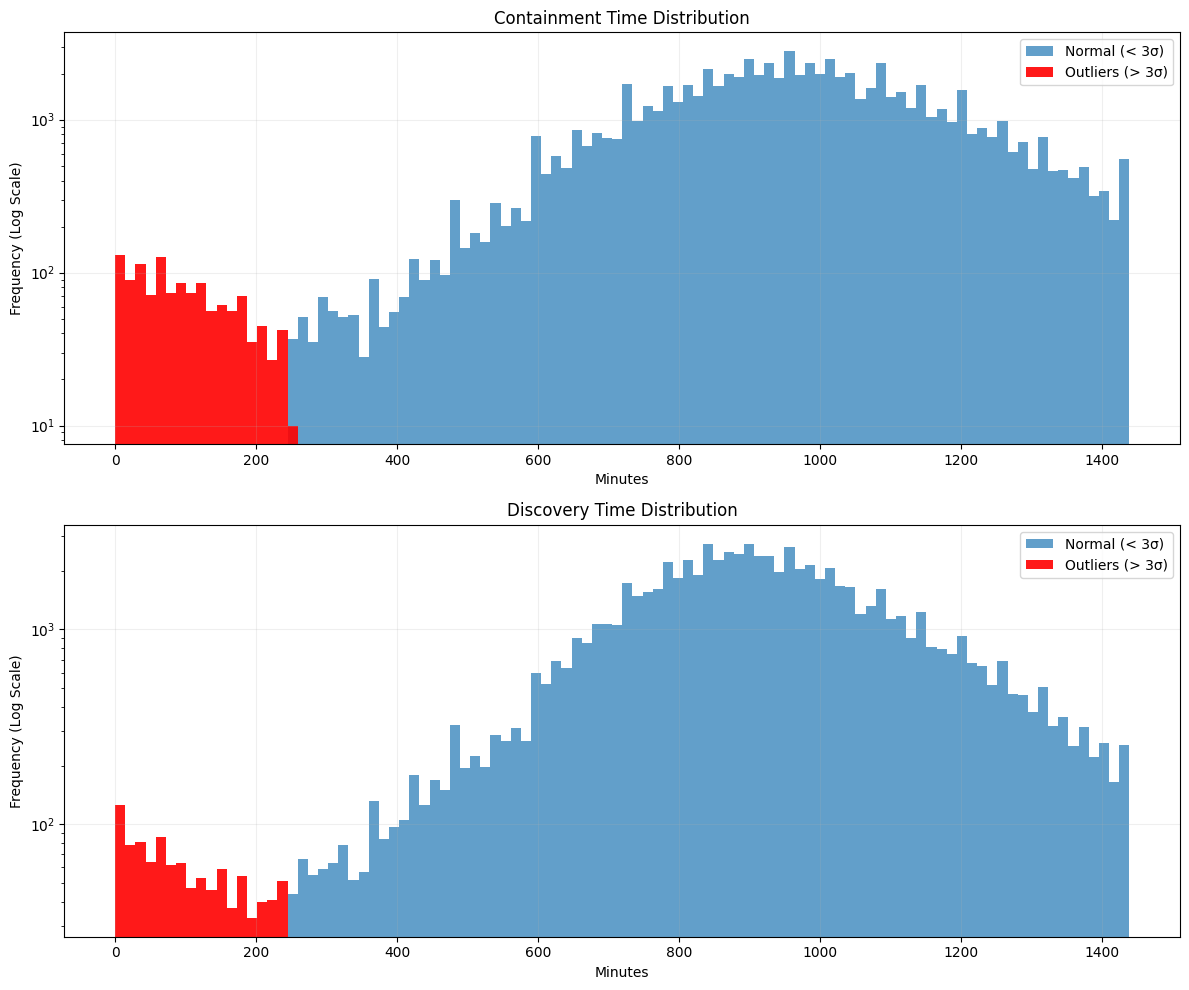

In [31]:
# Calculate Z-scores
cont_z = np.abs(zscore(X_train['CONT_TIME_MINUTES']))
disc_z = np.abs(zscore(X_train['DISCOVERY_TIME_MINUTES']))

# Split the data
cont_normal = X_train.loc[cont_z <= 3, 'CONT_TIME_MINUTES']
cont_outliers = X_train.loc[cont_z > 3, 'CONT_TIME_MINUTES']

disc_normal = X_train.loc[disc_z <= 3, 'DISCOVERY_TIME_MINUTES']
disc_outliers = X_train.loc[disc_z > 3, 'DISCOVERY_TIME_MINUTES']

# Define consistent bin edges
cont_bins = np.linspace(X_train['CONT_TIME_MINUTES'].min(),
                        X_train['CONT_TIME_MINUTES'].max(),
                        101)  # 101 edges = 100 bins

disc_bins = np.linspace(X_train['DISCOVERY_TIME_MINUTES'].min(),
                        X_train['DISCOVERY_TIME_MINUTES'].max(),
                        101)

# Create stacked plots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Containment Time histogram
axes[0].hist(cont_normal, bins=cont_bins, alpha=0.7, label='Normal (< 3σ)')
axes[0].hist(cont_outliers, bins=cont_bins, alpha=0.9, color='red', label='Outliers (> 3σ)')
axes[0].set_title('Containment Time Distribution')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Frequency (Log Scale)')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Discovery Time histogram
axes[1].hist(disc_normal, bins=disc_bins, alpha=0.7, label='Normal (< 3σ)')
axes[1].hist(disc_outliers, bins=disc_bins, alpha=0.9, color='red', label='Outliers (> 3σ)')
axes[1].set_title('Discovery Time Distribution')
axes[1].set_xlabel('Minutes')
axes[1].set_ylabel('Frequency (Log Scale)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

These should not be classified as outliers. Although fires start less often at night than during the day, these occurrences are expected and valid.

In [32]:
del cont_normal
del cont_outliers
del disc_normal
del disc_outliers

## Feature Scaling

## Normalisation and Standardisation

In [33]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [34]:
# Log transform FIRE_SIZE (add 1 to handle any zero values)
X_train['FIRE_SIZE_log'] = np.log1p(y_train)
X_test['FIRE_SIZE_log'] = np.log1p(y_test)

In [35]:
# Select numerical features
features_to_scale = ['FIRE_SIZE_log', 'DISCOVERY_TIME_MINUTES', 'CONT_TIME_MINUTES',
                     'LATITUDE', 'LONGITUDE', 'DISCOVERY_DOY', 'CONT_DOY', 'FIRE_YEAR']

In [36]:
# Scale features (fit on train only, transform both)

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

std_cols = [f + '_std' for f in features_to_scale]
norm_cols = [f + '_norm' for f in features_to_scale]

# Fit on training set only
X_train[std_cols] = scaler_std.fit_transform(X_train[features_to_scale])
X_train[norm_cols] = scaler_mm.fit_transform(X_train[features_to_scale])

# Transform test set using training set statistics
X_test[std_cols] = scaler_std.transform(X_test[features_to_scale])
X_test[norm_cols] = scaler_mm.transform(X_test[features_to_scale])

print("Training set scaled:")
print(X_train[std_cols].head())
print("\nTest set scaled:")
print(X_test[std_cols].head())

Training set scaled:
        FIRE_SIZE_log_std  DISCOVERY_TIME_MINUTES_std  CONT_TIME_MINUTES_std  \
139495          -0.611420                   -0.913433              -0.946146   
87148           -0.745392                    0.613055               0.564687   
8468            -0.611420                   -0.125276               0.825766   
8648            -0.679048                    0.522462               0.825766   
95104           -0.579692                   -2.523006               0.512556   

        LATITUDE_std  LONGITUDE_std  DISCOVERY_DOY_std  CONT_DOY_std  \
139495     -0.083826      -1.582747           0.722553      0.683491   
87148      -0.023204      -0.151016           1.260249      1.214757   
8468        0.381206      -0.858767           0.173655      0.141157   
8648        0.353089      -0.752475           0.800967      0.760967   
95104       0.841372       1.404014          -0.240819     -0.268360   

        FIRE_YEAR_std  
139495       0.946351  
87148        0.94

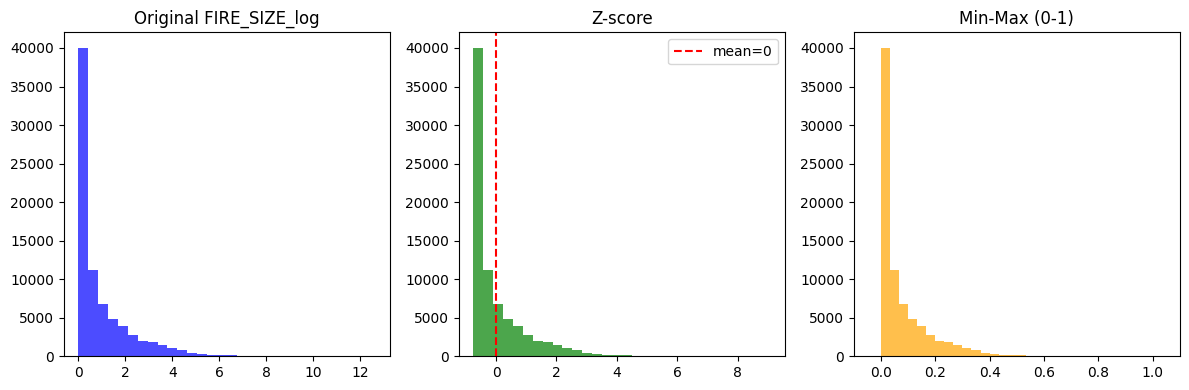

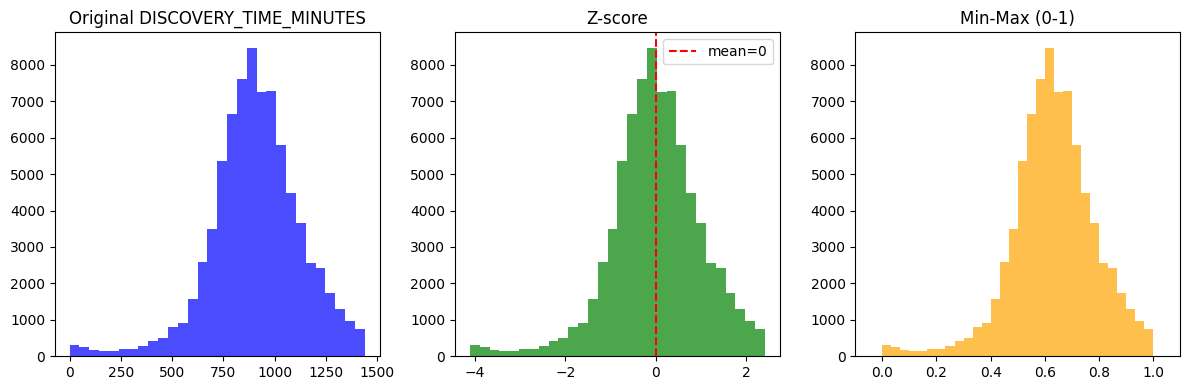

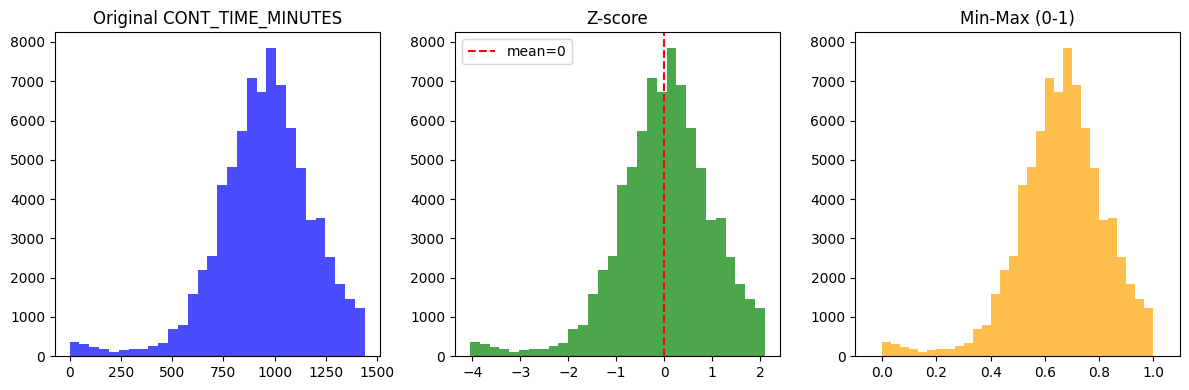

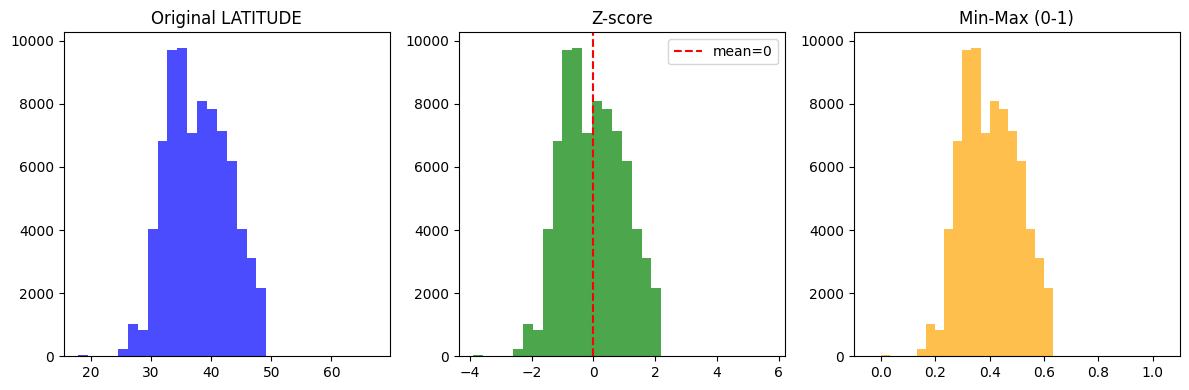

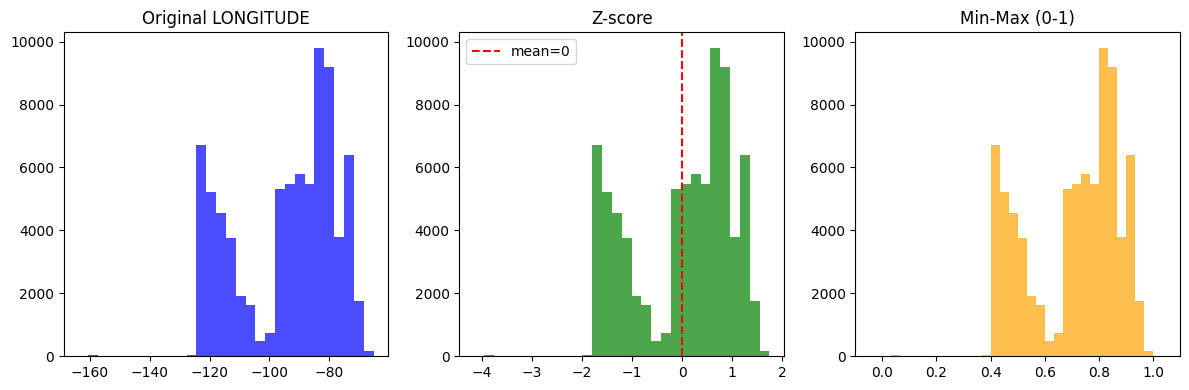

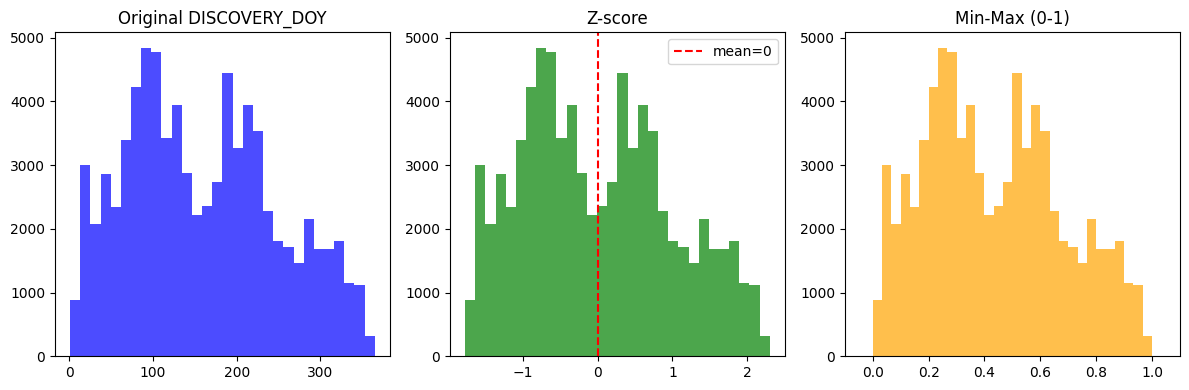

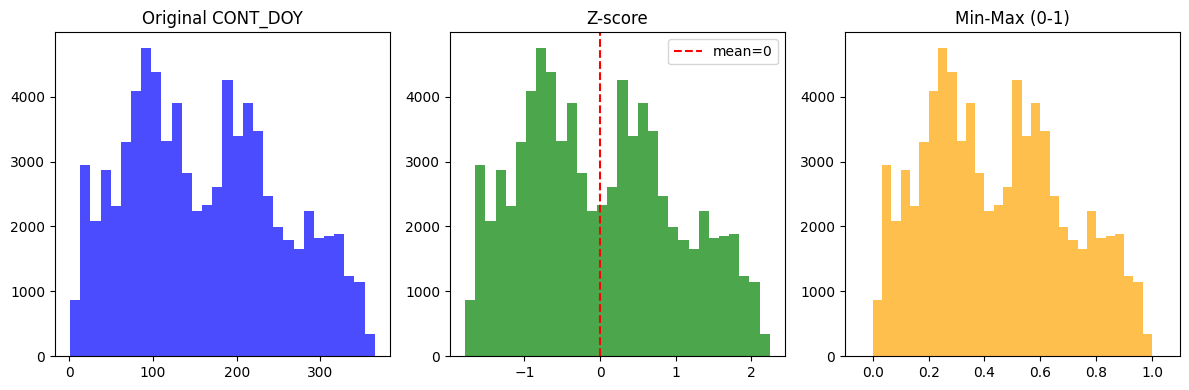

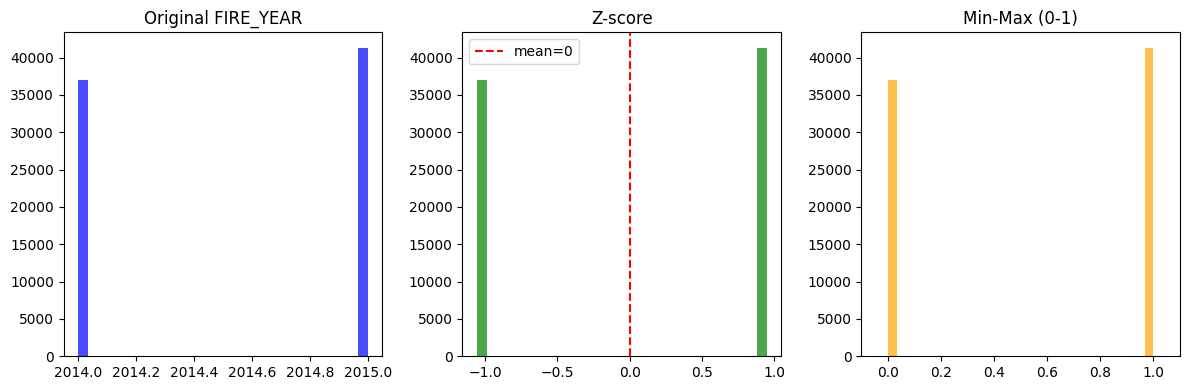

In [37]:
# Histogram for each feature
for feature in features_to_scale:
    plt.figure(figsize=(12, 4))

    bins = 30

    # Original
    plt.subplot(1, 3, 1)
    plt.hist(X_train[feature], bins=bins, color='blue', alpha=0.7)
    plt.title(f'Original {feature}')

    # Z-score
    plt.subplot(1, 3, 2)
    plt.hist(X_train[feature + '_std'], bins=30, color='green', alpha=0.7)
    plt.title('Z-score')
    plt.axvline(x=0, color='r', linestyle='--', label='mean=0')
    plt.legend()

    # Min-Max
    plt.subplot(1, 3, 3)
    plt.hist(X_train[feature + '_norm'], bins=30, color='orange', alpha=0.7)
    plt.title('Min-Max (0-1)')
    plt.xlim(-0.1, 1.1)

    plt.tight_layout()
    plt.show()

In [38]:
# Show skewness of the features we're scaling
print("Skewness of features:")
for feature in features_to_scale:
    print(f"{feature}: {X_train[feature].skew()}")

Skewness of features:
FIRE_SIZE_log: 2.3661188385415954
DISCOVERY_TIME_MINUTES: -0.5446538373134301
CONT_TIME_MINUTES: -0.7507831417762424
LATITUDE: 0.2282379075494365
LONGITUDE: -0.5192897959583048
DISCOVERY_DOY: 0.2930255143038056
CONT_DOY: 0.2514206500742729
FIRE_YEAR: -0.1103415231373879


#### FIRE_SIZE
The original FIRE_SIZE distribution is extremely right-skewed with most values clustered near 0 and a long tail extending to large fires. The x-axis uses log scale (10⁻³ to 10⁵) to even visualize the spread.

Z-score is NOT ideal for FIRE_SIZE due to its extreme skew (74.20). The massive outliers distort both the mean and standard deviation, making the standardized values unhelpful.

Min-Max is also problematic for FIRE_SIZE. The orange plot shows nearly all data compressed at 0 because the maximum fire size is so large compared to typical fires.

---

#### FIRE_SIZE_log (after log transform)

A log transform (log1p) was applied to FIRE_SIZE to reduce the extreme right skew. The transformed distribution is still right-skewed (skew: 2.37) but far more manageable, with values now spread across a visible range (0 to ~13) rather than spanning five orders of magnitude.

Z-score on the log-transformed values is the chosen approach. While the distribution is not perfectly normal, the log transform has reduced the skew from 74.20 to 2.37, which is sufficient for standardisation to produce meaningful centred values. This is the standard method for handling heavily skewed positive-valued features. Keep FIRE_SIZE_log_std.

Min-Max on the log-transformed values shows improved spread compared to the original, with data no longer entirely compressed at 0. However, the remaining right skew still causes most values to cluster in the lower range. Z-score is preferred. Drop FIRE_SIZE_log_norm.

---

#### DISCOVERY_TIME_MINUTES
The original DISCOVERY_TIME_MINUTES distribution is slightly left-skewed (skew: -0.53) with values ranging from 0 to approximately 1500 minutes, peaking around 800-1000 minutes.

Z-score works well for DISCOVERY_TIME_MINUTES due to its mild skew (-0.53) and approximately normal appearance. It preserves the distribution shape while standardizing the scale, making it suitable for combining with other features of different units. The standardized values reveal outliers (those beyond ±3) which represent unusually early or late fire discovery times.

Min-Max scaling is appropriate for DISCOVERY_TIME_MINUTES when bounded [0,1] values are needed. The scaled values are interpretable as relative discovery time (0 = earliest, 1 = latest). This works because there are no extreme outliers distorting the scale.

---

#### CONT_TIME_MINUTES
The original CONT_TIME_MINUTES distribution is slightly left-skewed (skew: -0.72) with values ranging from 0 to approximately 2000 minutes, peaking around 1000 minutes.

Z-score works well for CONT_TIME_MINUTES due to its mild skew (-0.72) and approximately normal appearance. It preserves the distribution shape while standardizing the scale, making it suitable for combining with other features. The standardized values reveal outliers (those beyond ±3) which represent unusually fast or slow containment times.

Min-Max scaling is appropriate for CONT_TIME_MINUTES when bounded [0,1] values are needed. The scaled values are interpretable as relative containment speed (0 = fastest containment, 1 = slowest). This works because there are no extreme outliers distorting the scale.

#### LATITUDE

The original LATITUDE distribution is roughly bell-shaped but slightly irregular, with the majority of values clustered between 30 and 50 degrees and a peak around 35-40.

Z-score works well for LATITUDE as it effectively centers the continental mass at 0 without being overly sensitive to the geographic outliers defining the boundaries.

Min-Max scaling is less effective here for visualizing the main distribution, as the outliers (likely Alaska or Hawaii) compress the continental US data into a small middle segment (0.2–0.6) rather than utilizing the full [0,1] range.

---

#### LONGITUDE

The original LONGITUDE distribution is distinctly bimodal (two separate peaks), representing the two major clusters of fire occurrences (likely Western vs. Eastern US) around -120 and -90.

Z-score is excellent for LONGITUDE because it respects the bimodal nature of the data while standardizing the scale, ensuring neither geographic cluster dominates the other in distance calculations.

Min-Max scaling again highlights the presence of extreme outliers (likely far-west coordinates like Hawaii or Alaska) which set the "0" point, causing the primary dataset to bunch up in the upper half of the scale.

---

#### DISCOVERY_DOY

The original DISCOVERY_DOY distribution is multimodal and broad, with distinct peaks around day 100 (Spring) and day 200 (Summer), and lower frequencies at the start/end of the year.

Z-score works well for DISCOVERY_DOY by centering the "average" fire date at 0, making it easy to identify fires that occurred unusually early or late in the season (tails of the distribution).

Min-Max scaling is highly effective for DISCOVERY_DOY as the data is naturally bounded (days 1-365) without extreme outliers, allowing the distribution to fill the [0,1] space meaningfully.

---

#### CONT_DOY

The original CONT_DOY distribution closely mirrors Discovery DOY, featuring a multimodal shape with peaks around day 100 and day 200.

Z-score is suitable for CONT_DOY, as it maintains the seasonal structure while standardizing the values for comparison with other features.

Min-Max scaling is also appropriate here, providing an intuitive "progress bar" of the fire season where 0 is the beginning of the year and 1 is the end.

---
##### FIRE_YEAR

The original FIRE_YEAR distribution shows two tall, narrow bars at 2014 and 2015, reflecting the discrete nature of the variable — it only takes integer year values across a very limited range.

Z-score is not particularly meaningful for FIRE_YEAR. With only two distinct values, standardisation simply maps them to approximately -1 and +1. The result conveys no useful distributional information beyond indicating which of the two years a record belongs to.

Min-Max scaling behaves similarly, collapsing the two years to 0 and 1. While technically valid, this is equivalent to binary encoding and offers no advantage over treating FIRE_YEAR as a categorical variable.

FIRE_YEAR will excluded from scaling because the dataset is filtered to only two years (2014–2015), leaving the variable with just two discrete values. In a dataset spanning many years, FIRE_YEAR could be meaningfully scaled and compared using both methods.

In [39]:
# Drop columns that are no longer needed
# --- Drop unwanted columns from both sets ---
cols_to_drop = [
    # Original columns
    'FIRE_SIZE_log',
    'DISCOVERY_TIME_MINUTES', 'CONT_TIME_MINUTES',
    'LATITUDE', 'LONGITUDE',
    'DISCOVERY_DATE', 'CONT_DATE',  # Already extracted DOY features
    'DISCOVERY_DOY', 'CONT_DOY',
    'FIRE_YEAR',
    'FIPS_CODE',  # Redundant with FIPS_NAME
    'FIRE_SIZE_CLASS',  # Retrieved from FIRE_SIZE, keeping it would be target leakage

    # Unwanted scaled versions
    'FIRE_SIZE_log_norm',
    'DISCOVERY_TIME_MINUTES_norm',
    'CONT_TIME_MINUTES_norm',
    'LATITUDE_norm',
    'LONGITUDE_norm',
    'DISCOVERY_DOY_std',
    'CONT_DOY_std',
    'FIRE_YEAR_std', 'FIRE_YEAR_norm',
]

X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)

print(f"Training columns ({len(X_train.columns)}):")
print(X_train.columns.tolist())

Training columns (18):
['FOD_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID', 'NWCG_REPORTING_UNIT_NAME', 'STAT_CAUSE_DESCR', 'OWNER_DESCR', 'STATE', 'COUNTY', 'FIPS_NAME', 'FIRE_SIZE_log_std', 'DISCOVERY_TIME_MINUTES_std', 'CONT_TIME_MINUTES_std', 'LATITUDE_std', 'LONGITUDE_std', 'DISCOVERY_DOY_norm', 'CONT_DOY_norm']


### Categorical Variables

In [40]:
# Check unique values for all categorical columns (using training set)
cat_cols = ['SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY',
            'NWCG_REPORTING_UNIT_NAME',
            'STAT_CAUSE_DESCR', 'OWNER_DESCR',
            'STATE', 'COUNTY', 'FIPS_NAME']

for col in cat_cols:
    counts = X_train[col].value_counts().sort_index()
    print(f"\n\n{col} — {X_train[col].nunique()} unique values")
    print(counts.to_string())



SOURCE_SYSTEM_TYPE — 2 unique values
SOURCE_SYSTEM_TYPE
FED       14983
NONFED    63331


SOURCE_SYSTEM — 4 unique values
SOURCE_SYSTEM
DOI-WFMI        4662
FS-FIRESTAT     9618
FWS-FMIS         703
ST-NASF        63331


NWCG_REPORTING_AGENCY — 5 unique values
NWCG_REPORTING_AGENCY
BLM        4661
BOR           3
FS         9621
FWS         704
ST/C&L    63325


NWCG_REPORTING_UNIT_NAME — 441 unique values
NWCG_REPORTING_UNIT_NAME
Ace Basin National Wildlife Refuge                                   3
Agassiz National Wildlife Refuge                                     2
Alabama Forestry Commission                                       3417
Alamosa National Wildlife Refuge                                     1
Alaska Maritime National Wildlife Refuge                             1
Allegheny National Forest                                            9
Alligator River National Wildlife Refuge                             7
Amador-El Dorado Unit                                            

In [41]:
# Frequency encoding for high-cardinality features
county_freq = X_train['COUNTY'].value_counts()
unit_freq = X_train['NWCG_REPORTING_UNIT_ID'].value_counts()

X_train['COUNTY_freq'] = X_train['COUNTY'].map(county_freq)
X_test['COUNTY_freq'] = X_test['COUNTY'].map(county_freq).fillna(0)

X_train['NWCG_REPORTING_UNIT_freq'] = X_train['NWCG_REPORTING_UNIT_ID'].map(unit_freq)
X_test['NWCG_REPORTING_UNIT_freq'] = X_test['NWCG_REPORTING_UNIT_ID'].map(unit_freq).fillna(0)

# Scale the frequency columns (fit on train only)
freq_scaler = StandardScaler()
X_train[['COUNTY_freq', 'NWCG_REPORTING_UNIT_freq']] = freq_scaler.fit_transform(
    X_train[['COUNTY_freq', 'NWCG_REPORTING_UNIT_freq']])
X_test[['COUNTY_freq', 'NWCG_REPORTING_UNIT_freq']] = freq_scaler.transform(
    X_test[['COUNTY_freq', 'NWCG_REPORTING_UNIT_freq']])

# Drop the original high-cardinality columns
X_train.drop(columns=['COUNTY', 'FIPS_NAME', 'NWCG_REPORTING_UNIT_ID', 'NWCG_REPORTING_UNIT_NAME'], inplace=True)
X_test.drop(columns=['COUNTY', 'FIPS_NAME', 'NWCG_REPORTING_UNIT_ID', 'NWCG_REPORTING_UNIT_NAME'], inplace=True)

print("Frequency encoded columns (training set):")
print(X_train[['COUNTY_freq', 'NWCG_REPORTING_UNIT_freq']].describe())

Frequency encoded columns (training set):
        COUNTY_freq  NWCG_REPORTING_UNIT_freq
count  7.831400e+04              7.831400e+04
mean   3.955827e-17              1.070614e-16
std    1.000006e+00              1.000006e+00
min   -8.883316e-01             -1.114285e+00
25%   -6.177663e-01             -9.574286e-01
50%   -3.287534e-01             -4.667860e-01
75%    1.447358e-01              1.047157e+00
max    4.781241e+00              1.837974e+00


COUNTY (1942 unique), FIPS_NAME (1394), NWCG_REPORTING_UNIT_ID (456), and NWCG_REPORTING_UNIT_NAME (455) have too many categories for one-hot encoding. COUNTY and FIPS_NAME overlap (both represent county-level geography), as do the NWCG ID/NAME pair. Keeping COUNTY and NWCG_REPORTING_UNIT_ID avoids redundancy.
Frequency encoding replaces each category with its occurrence count from the training set, creating a single numeric column instead of thousands of sparse dummies. Unseen test categories receive 0 (prevents leakage). Frequencies are then standardised. Note that counts reflect this 2014–2015 subset — a rare county may simply have had fewer fires in this period rather than being low-risk generally.

In [42]:
# One-Hot Encoding for low/medium cardinality features
cols_to_encode = ['SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY',
                  'STAT_CAUSE_DESCR', 'OWNER_DESCR', 'STATE']

X_train = pd.get_dummies(X_train, columns=cols_to_encode, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_to_encode, drop_first=True)

# Align columns - test set may be missing categories that only appear in train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Training shape after encoding: {X_train.shape}")
print(f"Test shape after encoding: {X_test.shape}")

Training shape after encoding: (78314, 93)
Test shape after encoding: (19554, 93)


Features with manageable cardinality (SOURCE_SYSTEM_TYPE: 2, SOURCE_SYSTEM: 4, NWCG_REPORTING_AGENCY: 5, STAT_CAUSE_DESCR: 13, OWNER_DESCR: 15, STATE: 50) are one-hot encoded. drop_first=True removes one category per feature to avoid the dummy variable trap (multicollinearity).
Encoding is applied separately to train and test, then test columns are aligned to match training using reindex. Categories in test but not train are dropped; categories in train but not test are filled with 0.

In [43]:
X_train.shape

(78314, 93)

In [44]:
# Target: log-transformed FIRE_SIZE
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Remove FIRE_SIZE_log_std from features (derived from target) and FOD_ID
X_train.drop(columns=['FIRE_SIZE_log_std', 'FOD_ID'], inplace=True)
X_test.drop(columns=['FIRE_SIZE_log_std', 'FOD_ID'], inplace=True)

print(f"Features: {X_train.shape[1]}")
print(f"Target example (first 5): {y_train_log.values[:5]}")

Features: 91
Target example (first 5): [0.18232156 0.00995033 0.18232156 0.09531018 0.22314355]


Log-transforming FIRE_SIZE (using log1p for zeros) reduces extreme right skew, helping linear regression assumptions. FIRE_SIZE_log_std is removed — it's derived from the target and would leak the answer. FOD_ID is just an identifier with no predictive value.

# Objective

Design, implement, and evaluate a neural network model on a dataset of your choice.
This exercise focuses on understanding different neural network architectures and their evaluation.

---

# Task Description

Work in groups of 3–5 students.
Choose one neural network architecture and apply it to a suitable dataset.

You may select one of the following models:
- Feedforward Neural Network (FNN / MLP)
- Recurrent Neural Network (RNN)
- Long Short-Term Memory (LSTM)
- Convolutional Neural Network (CNN)

You may choose any dataset appropriate for your selected model and task.

---

# Problem Type

Choose one:
- Classification task
- Regression task

---

# Model Evaluation
## If Classification:

Evaluate your model using:
- Accuracy
- Precision
- Recall
- F1-score

## If Regression:
Evaluate your model using:
- RMSE (Root Mean Squared Error)

# Neural Network

## Neural Network Architecture Selection

### Feedforward Neural Network (MLP)

The dataset consists of independent wildfire events with tabular features (spatial coordinates, temporal variables, categorical causes). Each observation is cross-sectional rather than sequential.

**Why MLP:**
- Designed for tabular data with mixed feature types (continuous, categorical)
- Can learn complex non-linear interactions between features (e.g., geography × seasonality)
- MLP can capture complex feature interactions through global optimisation

**Why Not RNN/LSTM:**
- Require sequential data where order matters (time series, text sequences)
- Our data: independent fire events with no temporal dependencies between observations
- No causal relationship between fires in the dataset

**Why Not CNN:**
- Designed for spatial grid data (images, spatial fields)
- Our spatial data is coordinate-based (lat/long), not gridded imagery
- Would require artificial grid creation

In [45]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

2026-02-17 20:47:59.055236: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-17 20:47:59.869006: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-17 20:48:04.606968: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [46]:
np.random.seed(42)
tf.random.set_seed(42)

In [47]:
# Split training data for validation
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train, y_train_log, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train_nn)}")
print(f"Validation samples: {len(X_val_nn)}")
print(f"Test samples: {len(X_test)}")

Training samples: 62651
Validation samples: 15663
Test samples: 19554


The validation set (20% of training data, ~15,600 samples) is held out to monitor model performance during training.

In [48]:
# Build MLP architecture
def build_mlp(input_dim, dropout_rate=0.1, l2_reg=0.001):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # First hidden layer
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        # Second hidden layer
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        # Third hidden layer
        layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        # Output layer (linear activation for regression)
        layers.Dense(1)
    ])

    return model

## Architecture Justification

The MLP architecture employs three hidden layers with decreasing dimensions (128, 64, 32). The first layer (128 units) exceeds the input feature count (~100+ features after encoding), allowing the network to project inputs into a higher-dimensional space where non-linear feature interactions become linearly separable. Each subsequent layer halves the previous dimension, forcing the network to discard redundant information and retain only the most predictive signal — if all layers were equally wide, the network could pass information through unchanged without learning compressed representations. The final layer (32 units) maps to a single regression output.

ReLU activation was selected for all hidden layers. Unlike sigmoid or tanh, whose derivatives are bounded below 1 (maximum 0.25 for sigmoid), ReLU has a gradient of exactly 1 for positive inputs. Across three hidden layers, sigmoid gradients compound multiplicatively (e.g., 0.25³ = 0.016), effectively preventing early layers from updating their weights. ReLU avoids this, maintaining gradient magnitude through the network. The output layer uses linear activation, appropriate for regression where predictions are unconstrained.

L2 regularisation (0.001) is applied to all hidden layer weights, penalising large values to reduce overfitting. This strength is proportionate to the scale of the problem: the network has approximately 15,000 trainable parameters across three layers, and a penalty of 0.001 constrains weights without dominating the primary loss term. For context, the Huber training loss converges around 0.36, while the total L2 penalty at this strength contributes roughly 0.01–0.05 to the loss — sufficient to discourage extreme weights but not so large as to suppress learning.

Batch normalisation is applied after each dense layer to standardise intermediate activations, reducing internal covariate shift and stabilising gradient flow during training. This permits faster convergence and reduces sensitivity to weight initialisation. Batch normalisation can conflict with dropout: during training, dropout zeros a subset of activations, which alters the variance of each layer's output. Batch normalisation accumulates these variance statistics during training. At inference time, dropout is disabled, so the actual variance changes — but batch normalisation still uses the statistics it collected during training when dropout was active. This mismatch between training-time and inference-time variance can degrade predictions. Li et al. (2019) analyse this conflict and conclude that the severity is proportional to the dropout rate — lower dropout rates produce smaller mismatches. Their practical guideline recommends a drop ratio below 0.5 when combining dropout with batch normalisation (Section 6, Li et al. 2019). Our dropout rate of 0.1 is well within this safe range.

Dropout (rate: 0.1) is applied after batch normalisation in each hidden layer, randomly deactivating 10% of neurons during each training step to prevent co-adaptation of features. This rate is appropriate for two reasons: first, with ~62,000 training samples and three hidden layers, overfitting risk is moderate, so aggressive regularisation is unnecessary; second, a low rate minimises the conflict with batch normalisation described above.

Huber loss (delta=1.0) was chosen over mean squared error due to the target distribution characteristics. Despite log transformation, the target variable retains a right skew of 2.37 (shown in the feature scaling analysis above). The original fire size distribution exhibits extreme outliers. Huber loss transitions from quadratic to linear behaviour for residuals exceeding delta, reducing the disproportionate influence of these extreme observations on gradient updates whilst maintaining smooth optimisation near zero. The delta of 1.0 means that in log-space, any prediction error exceeding ~1 log-unit (roughly a factor of 2.7 in acres) is penalised linearly rather than quadratically.

The Adam optimiser with its default learning rate of 0.001 was selected, providing adaptive per-parameter learning rates through first and second moment estimation of gradients.

**Reference:** Li, X., Chen, S., Hu, X. and Yang, J. (2019) 'Understanding the Disharmony between Dropout and Batch Normalization by Variance Shift', *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)*, pp. 2682–2690.

In [49]:
from itertools import product

param_grid = {
    'dropout_rate': [0.1, 0.2, 0.3],
    'l2_reg': [0.0001, 0.001, 0.01]
}

results = []

for dr, l2 in product(param_grid['dropout_rate'],
                      param_grid['l2_reg']):
    model = build_mlp(input_dim=X_train_nn.shape[1], dropout_rate=dr, l2_reg=l2)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )

    early_stop = EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=0
    )

    history = model.fit(
        X_train_nn, y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=100, batch_size=256,
        callbacks=[early_stop], verbose=0
    )

    val_loss = min(history.history['val_loss'])
    val_mae = min(history.history['val_mae'])
    epochs_trained = len(history.history['loss'])

    results.append({
        'dropout': dr, 'l2': l2,
        'val_loss': val_loss, 'val_mae': val_mae,
        'epochs': epochs_trained
    })

results_df = pd.DataFrame(results).sort_values('val_loss')
print("\nAll configurations:")
display(results_df)

best = results_df.iloc[0]
print(f"\nBest: dropout={best['dropout']}, l2={best['l2']}")


All configurations:


,dropout,l2,val_loss,val_mae,epochs
3,0.2,0.0001,0.328617,0.592279,33
6,0.3,0.0001,0.329850,0.601600,36
0,0.1,0.0001,0.333252,0.597302,27
1,0.1,0.0010,0.339705,0.606011,27
4,0.2,0.0010,0.343857,0.613638,21
7,0.3,0.0010,0.344474,0.610881,25
2,0.1,0.0100,0.352308,0.621370,20
5,0.2,0.0100,0.359658,0.631142,16
8,0.3,0.0100,0.360403,0.635561,25



Best: dropout=0.2, l2=0.0001


### Hyperparameter Tuning

Key hyperparameters were selected via grid search over dropout rate (0.1, 0.2, 0.3) and L2 regularisation strength (0.0001, 0.001, 0.01). The Adam learning rate was held at its default of 0.001, as this is the most established configuration and tuning it would triple the search space without proportionate benefit for a shallow three-layer network. The architecture (layer sizes, activation functions, loss function) was held constant across all configurations, isolating the effect of regularisation strength.

Each configuration was trained with early stopping (patience=5) on the validation set, monitoring validation loss (Huber) rather than MAE — since Huber loss is the objective the model optimises, monitoring a different metric could terminate training at a point suboptimal for the actual objective. A reduced patience of 5 was used during the search to limit computation time.

A batch size of 256 was used throughout tuning and final training. Keras defaults to a batch size of 32, but with ~62,000 training samples this would produce ~1,940 updates per epoch, significantly slowing both individual runs and the overall grid search. A batch size of 256 reduces this to ~306 updates per epoch whilst still providing enough samples per batch for the gradient estimate to remain representative of the full dataset.

Each configuration was trained with early stopping (patience=5) on the validation set, monitoring validation loss (Huber) rather than MAE — since Huber loss is the objective the model optimises, monitoring a different metric could terminate training at a point suboptimal for the actual objective. `restore_best_weights=True` ensures that each configuration is evaluated at its best epoch rather than its final epoch, making comparisons fair across configurations with different convergence speeds. A reduced patience of 5 was used during the search to limit computation time, with the final model trained using patience of 10 to allow fuller convergence.

In [50]:
# Model with best hyperparameters
mlp_model = build_mlp(
    input_dim=X_train_nn.shape[1],
    dropout_rate=best['dropout'],
    l2_reg=best['l2']
)

mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.Huber(delta=1.0),
    metrics=['mae', 'mse']
)

mlp_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 128)            │        11,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,041 (90.00 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 448 (1.75 KB)

## Model Training

### Training Configuration

The final model was retrained using the optimal hyperparameters from the grid search, with early stopping patience set back to default (10) to allow fuller convergence. All other training parameters (batch size, optimiser, loss function, monitoring metric) remain identical to the tuning phase.

In [51]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = mlp_model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6190 - mae: 0.9559 - mse: 2.1319 - val_loss: 0.4341 - val_mae: 0.7309 - val_mse: 1.5200
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4603 - mae: 0.7657 - mse: 1.5229 - val_loss: 0.3961 - val_mae: 0.6675 - val_mse: 1.3606
Epoch 3/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4189 - mae: 0.7115 - mse: 1.3825 - val_loss: 0.3722 - val_mae: 0.6458 - val_mse: 1.2576
Epoch 4/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3971 - mae: 0.6825 - mse: 1.3123 - val_loss: 0.3639 - val_mae: 0.6334 - val_mse: 1.2115
Epoch 5/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3848 - mae: 0.6678 - mse: 1.2628 - val_loss: 0.3592 - val_mae: 0.6250 - val_mse: 1.1856
Epoch 6/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3783 - mae: 0.6595 - mse: 1.2379 - val_loss: 0.3552 - val_mae: 0.6302 - val_mse: 1.1545
Epoch 7/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3719 - mae: 0.6527 - mse: 1.213

### Training Results

The model trained for 46 epochs before early stopping triggered, with best performance at epoch 36:
- Training loss: 0.3311
- Validation loss: 0.3288
- Validation MAE: 0.5969

Training loss remains above validation loss throughout training. This is expected behaviour when using dropout: dropout is active during training (artificially increasing training loss by deactivating neurons) but disabled during validation, giving the validation set an easier path through the full network. Both curves converge and flatten by epoch 30, with early stopping allowing 10 further epochs to confirm no improvement before restoring epoch 36 weights.

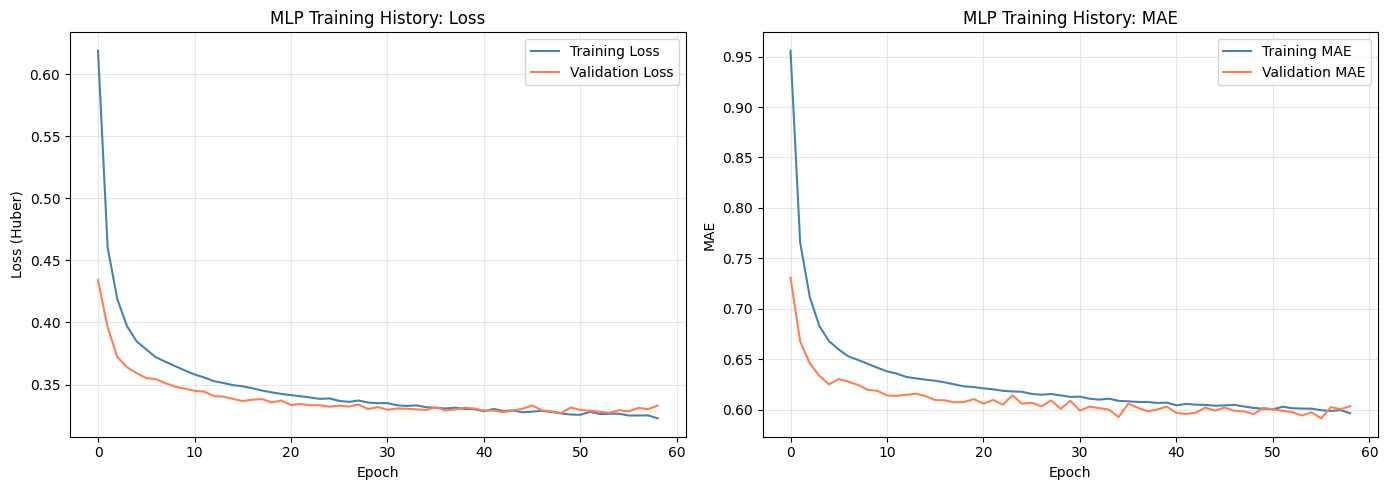

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='coral')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Huber)')
axes[0].set_title('MLP Training History: Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='coral')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('MLP Training History: MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# Evaluate on test set
y_pred_mlp = mlp_model.predict(X_test).flatten()

# Log-space metrics
r2_mlp = r2_score(y_test_log, y_pred_mlp)
rmse_mlp_log = root_mean_squared_error(y_test_log, y_pred_mlp)
mae_mlp_log = mean_absolute_error(y_test_log, y_pred_mlp)

print("Log-space metrics:")
print(f"R²:{r2_mlp:.4f}")
print(f"RMSE:{rmse_mlp_log:.4f}")
print(f"MAE:{mae_mlp_log:.4f}")

# Back-transform to original scale (acres)
y_pred_original = np.expm1(y_pred_mlp)
y_test_original = np.expm1(y_test_log)

rmse_mlp_original = root_mean_squared_error(y_test_original, y_pred_original)
mae_mlp_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nOriginal-scale metrics (acres):")
print(f"RMSE:{rmse_mlp_original:.2f}")
print(f"MAE:{mae_mlp_original:.2f}")

612/612 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Log-space metrics:
R²:0.3408
RMSE:1.0662
MAE:0.6143

Original-scale metrics (acres):
RMSE:3120.15
MAE:92.42


### Evaluation

Log-space metrics reflect the model's performance in the space it was trained on. The R² of 0.33 indicates the model explains roughly a third of the variance in log-transformed fire size — a limited but non-trivial result given that wildfire size is influenced by many factors not captured in this dataset (wind conditions, fuel moisture, suppression response time). The log-space RMSE of 1.07 corresponds to a typical prediction error of approximately one log-unit, meaning the model's predictions are on average off by a factor of ~2.9 in acres (e^1.07 ≈ 2.9).

Original-scale metrics are reported using `expm1` (the inverse of `log1p`) to convert predictions back to acres. The original-scale RMSE of 3,119 acres is dominated by large fires — the median fire in this dataset is 0.5 acres, so a small number of extreme mispredictions on large fires inflate this metric substantially. The original-scale MAE of 94 acres provides a more representative measure of typical error, though still heavily influenced by the right tail. Both are reported because log-space R² can appear moderate while original-scale RMSE reveals the disproportionate impact of extreme fires on prediction accuracy.

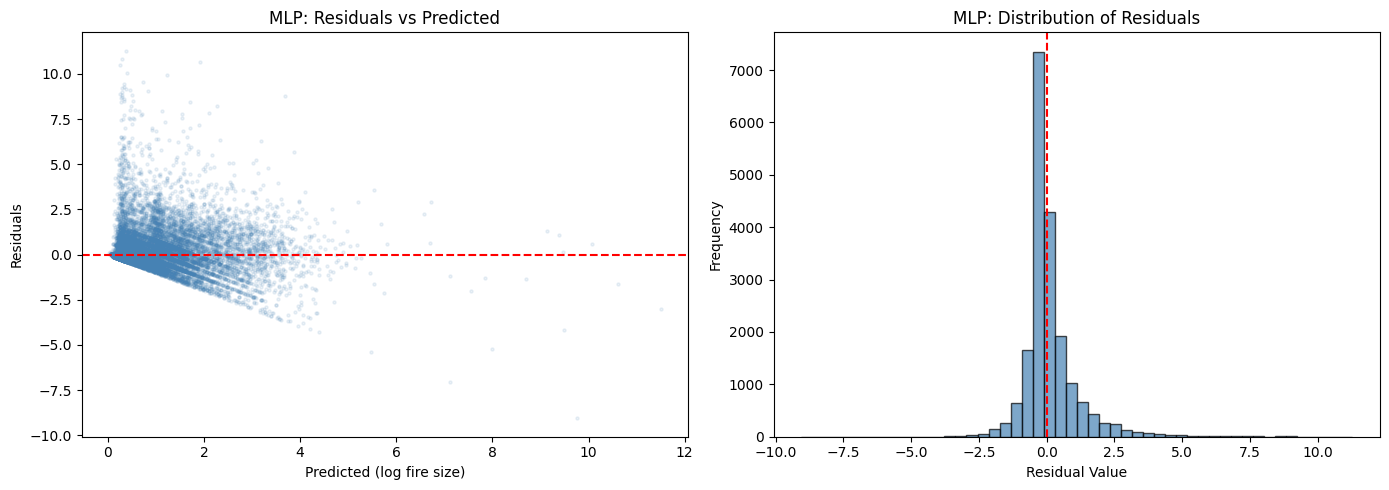

Mean residual: 0.1169
Std residual: 1.0598


In [54]:
residuals_mlp = y_test_log - y_pred_mlp

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_mlp, residuals_mlp, alpha=0.1, s=5, color='steelblue')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted (log fire size)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('MLP: Residuals vs Predicted')

axes[1].hist(residuals_mlp, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('MLP: Distribution of Residuals')

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals_mlp.mean():.4f}")
print(f"Std residual: {residuals_mlp.std():.4f}")

### Residual Analysis

The residuals-vs-predicted plot (left) shows a fan shape: residual spread is widest at low predicted values (0–2 in log-space) and narrows at higher predictions. This indicates heteroscedasticity — the model predicts small fires with less precision than large ones. This is expected: the majority of fires in the dataset are small (median 0.5 acres), and small fires have highly variable actual sizes relative to their predicted values. The visible diagonal banding at low predictions suggests the model collapses many fires with different true sizes onto similar predicted values, reflecting the limited discriminative power at the small end of the distribution.

The residual distribution (right) is centred near zero, confirming no systematic bias in predictions. However, the distribution is right-skewed with a long positive tail extending beyond +10, meaning the model more frequently underpredicts fire size (actual > predicted) than overpredicts. This is consistent with the target distribution: extremely large fires are rare and difficult to predict from the available features, so the model defaults to conservative (lower) predictions that occasionally fall far short of the true value.

This residual pattern also validates the choice of Huber loss — under MSE, these large positive residuals would have dominated gradient updates and pulled the model toward overpredicting for the majority of small fires.

# Task Description
Continue working with the same dataset used in Group Exercise 3.

Apply two different clustering methods to your data:
- K-Means clustering
- DBSCAN clustering

This task is intended to compare partition-based and density-based clustering approaches.

---

# Clustering Requirements

## 1. K-Means Clustering
- Apply K-Means with:

    - k = 2 clusters
- Clearly report the chosen value of k
- Visualise the resulting clusters (if possible)

## 2. DBSCAN Clustering
- Apply DBSCAN
- Clearly state the chosen parameters:
    - eps
    - min_samples
- Report:
    - number of clusters found
    - number of noise points (if any)

---

# Analysis and Comparison

Briefly compare K-Means and DBSCAN in terms of:
- cluster shape and structure
- sensitivity to noise and outliers
- suitability for your dataset

In [55]:
from sklearn.decomposition import PCA

In [56]:
# Combine train and test for clustering (unsupervised — no train/test distinction needed)
X_all = pd.concat([X_train, X_test], axis=0)
y_all_log = pd.concat([y_train_log, y_test_log], axis=0)

feature_names = X_all.columns.tolist()

# Apply PCA retaining 90% of variance
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_all)

print(f"Original features: {X_all.shape[1]}")
print(f"Components retained: {X_pca.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.1%}")

Original features: 91
Components retained: 16
Variance explained: 90.4%


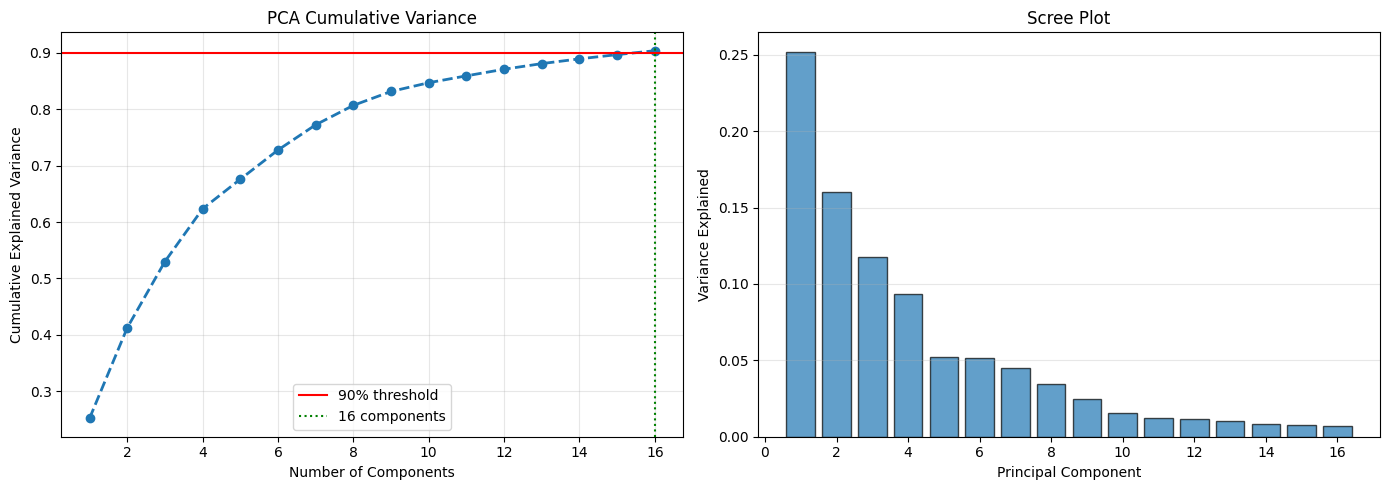

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cumsum = np.cumsum(pca.explained_variance_ratio_)
ax1.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linestyle='--', linewidth=2)
ax1.axhline(y=0.90, color='r', linestyle='-', label='90% threshold')
ax1.axvline(x=len(cumsum), color='g', linestyle=':', label=f'{len(cumsum)} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title('PCA Cumulative Variance')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_,
        alpha=0.7,
        edgecolor='black')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained')
ax2.set_title('Scree Plot')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [58]:
print("Top Feature Loadings for All Components:")
for i in range(X_pca.shape[1]):
    loadings = pca.components_[i]
    top_indices = np.argsort(np.abs(loadings))[::-1][:5]

    print(f"\nPC{i + 1} ({pca.explained_variance_ratio_[i]:.1%} variance):")
    for idx in top_indices:
        direction = "+" if loadings[idx] > 0 else "-"
        print(f"  {direction}{abs(loadings[idx]):.3f} x {feature_names[idx]}")

Top Feature Loadings for All Components:

PC1 (25.2% variance):
  +0.568 x LONGITUDE_std
  +0.541 x NWCG_REPORTING_UNIT_freq
  -0.329 x LATITUDE_std
  +0.183 x NWCG_REPORTING_AGENCY_ST/C&L
  +0.182 x SOURCE_SYSTEM_TYPE_NONFED

PC2 (16.0% variance):
  +0.690 x DISCOVERY_TIME_MINUTES_std
  +0.673 x CONT_TIME_MINUTES_std
  +0.191 x LATITUDE_std
  -0.105 x LONGITUDE_std
  -0.102 x NWCG_REPORTING_UNIT_freq

PC3 (11.7% variance):
  +0.903 x COUNTY_freq
  -0.252 x LATITUDE_std
  +0.194 x OWNER_DESCR_MISSING/NOT SPECIFIED
  -0.129 x OWNER_DESCR_PRIVATE
  -0.117 x LONGITUDE_std

PC4 (9.3% variance):
  +0.839 x LATITUDE_std
  +0.332 x NWCG_REPORTING_UNIT_freq
  +0.163 x COUNTY_freq
  +0.162 x STATE_NY
  +0.160 x LONGITUDE_std

PC5 (5.2% variance):
  +0.703 x DISCOVERY_TIME_MINUTES_std
  -0.701 x CONT_TIME_MINUTES_std
  -0.092 x LATITUDE_std
  -0.034 x COUNTY_freq
  +0.028 x STAT_CAUSE_DESCR_Lightning

PC6 (5.2% variance):
  +0.519 x NWCG_REPORTING_UNIT_freq
  -0.392 x OWNER_DESCR_PRIVATE
  -0.26

# Clustering Analysis

## Dimensionality Reduction with PCA

The preprocessed dataset contains 100+ features after one-hot encoding. Clustering algorithms, particularly DBSCAN, perform poorly in high-dimensional spaces: distance metrics become less meaningful as dimensionality increases, because the relative difference between the nearest and farthest points shrinks (Aggarwal et al., 2001). K-Means is also affected, as it relies on Euclidean distance. Principal Component Analysis (PCA) is applied to reduce dimensionality whilst retaining the dominant variance structure of the data.

### PCA Results

PCA reduces the 91-feature space to 16 principal components explaining 90.4% of cumulative variance. Jolliffe (2002) recommends thresholds of 70–90% for typical applications. A 90% threshold was selected at the upper end of this range: lower thresholds would risk discarding patterns relevant to cluster separation, while higher thresholds (e.g. 95%) would retain 20+ components with diminishing returns for clustering in distance-based algorithms.

The scree plot shows no sharp elbow — variance contributions decline gradually, with the first four components accounting for 62.2% collectively. This indicates that the dataset's variance is distributed across multiple independent dimensions rather than dominated by a single factor, which is expected given the mixed nature of the features (spatial, temporal, categorical).

The first component (25.2%) captures an east-west geographic and administrative pattern, with strong loadings on longitude and reporting unit frequency. The second component (16.0%) isolates temporal patterns through discovery and containment time. The third component (11.7%) reflects fire frequency at the county level. The fourth component (9.3%) captures the north-south geographic axis through latitude. Together, these four components represent the dominant spatial, temporal, and frequency dimensions of the data.

Components 5–9 capture progressively more specific patterns: the contrast between discovery and containment timing (PC5), land ownership and reporting system distinctions (PC6–PC8), and fire cause categories such as debris burning versus miscellaneous (PC9). Components 10–16 isolate individual cause types, seasonality, and state-specific patterns, each contributing under 1.5% individually.

The orthogonality of principal components eliminates a practical problem with clustering on the raw feature set: the 91 features include approximately 50 one-hot encoded state dummies, meaning geographic location would receive 50 dimensions of influence in Euclidean distance calculations while a single continuous feature like discovery time receives only one. PCA collapses correlated state dummies into a small number of geographic components, ensuring no single feature category dominates distance calculations by virtue of occupying more columns.

References:
Jolliffe, I.T. (2002) Principal Component Analysis, 2nd edn. New York: Springer.

In [59]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

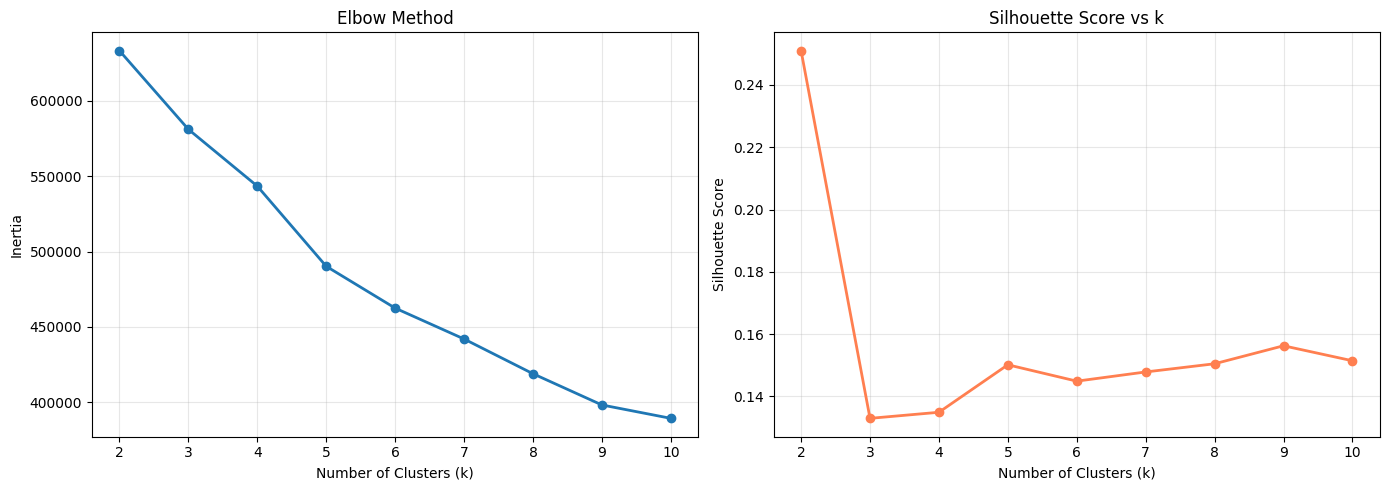

,inertia,silhouette
k,,
2,633114.749531,0.251006
3,581007.842531,0.132953
4,543350.344811,0.134903
5,490228.198975,0.150150
6,462513.417788,0.144894
7,442039.331962,0.147848
8,419020.406834,0.150479
9,398325.072715,0.156256
10,389451.558084,0.151442


In [60]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, marker='o', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, marker='o', linewidth=2, color='coral')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pd.DataFrame({'k': k_range, 'inertia': inertias, 'silhouette': silhouette_scores}).set_index('k')

In [61]:
best_k = silhouette_scores.index(max(silhouette_scores)) + 2

configs = {'k=2': 2}
if best_k != 2:
    configs[f'k={best_k}'] = best_k

km_results = {}
for name, k in configs.items():
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024)
    labels = km.fit_predict(X_pca)
    km_results[name] = {
        'model': km,
        'labels': labels,
        'silhouette': silhouette_score(X_pca, labels),
        'sizes': np.bincount(labels)
    }

pd.DataFrame({name: {'silhouette': r['silhouette'], **{f'cluster_{i}': s for i, s in enumerate(r['sizes'])}}
              for name, r in km_results.items()}).T

,silhouette,cluster_0,cluster_1
k=2,0.251006,64411.0,33457.0


In [62]:
# Profile using original unscaled values from df
original_cols = ['LATITUDE', 'LONGITUDE', 'DISCOVERY_TIME',
                 'CONT_TIME', 'DISCOVERY_DOY', 'CONT_DOY', 'FIRE_YEAR']

cluster_profile_df = df.loc[X_all.index, original_cols].copy()
cluster_profile_df['FIRE_SIZE'] = df.loc[X_all.index, 'FIRE_SIZE'].values
cluster_profile_df['cluster'] = km_results['k=2']['labels']

continuous = ['LATITUDE', 'LONGITUDE', 'DISCOVERY_TIME',
              'CONT_TIME', 'DISCOVERY_DOY', 'CONT_DOY', 'FIRE_YEAR']
skewed = ['FIRE_SIZE']

binary = [c for c in X_all.columns if c not in
          ['LATITUDE_std', 'LONGITUDE_std', 'DISCOVERY_TIME_MINUTES_std',
           'CONT_TIME_MINUTES_std', 'DISCOVERY_DOY_norm', 'CONT_DOY_norm',
           'COUNTY_freq', 'NWCG_REPORTING_UNIT_freq']]

profiles = []
for feat in continuous:
    row = {'Feature': feat, 'Measure': 'mean'}
    for cid in sorted(cluster_profile_df['cluster'].unique()):
        val = cluster_profile_df[cluster_profile_df['cluster'] == cid][feat].mean()
        row[f'Cluster {cid}'] = f"{val:.2f}"
    profiles.append(row)

for feat in skewed:
    row = {'Feature': feat, 'Measure': 'median'}
    for cid in sorted(cluster_profile_df['cluster'].unique()):
        val = cluster_profile_df[cluster_profile_df['cluster'] == cid][feat].median()
        row[f'Cluster {cid}'] = f"{val:.2f}"
    profiles.append(row)

cluster_binary_df = X_all.copy()
cluster_binary_df['cluster'] = km_results['k=2']['labels']
for feat in binary:
    row = {'Feature': feat, 'Measure': 'proportion'}
    for cid in sorted(cluster_binary_df['cluster'].unique()):
        val = cluster_binary_df[cluster_binary_df['cluster'] == cid][feat].mean()
        row[f'Cluster {cid}'] = f"{val:.1%}"
    profiles.append(row)

profile_km2 = pd.DataFrame(profiles).set_index('Feature')
profile_km2

,Measure,Cluster 0,Cluster 1
Feature,,,
LATITUDE,mean,36.28,40.93
LONGITUDE,mean,-84.08,-114.19
DISCOVERY_TIME,mean,1520.45,1443.07
CONT_TIME,mean,1605.54,1489.14
DISCOVERY_DOY,mean,144.46,187.99
...,...,...,...
STATE_VA,proportion,0.0%,0.1%
STATE_WA,proportion,0.0%,7.4%
STATE_WI,proportion,1.8%,1.2%


In [63]:
if best_k != 2:
    cluster_df['cluster'] = km_results[f'k={best_k}']['labels']

    profiles = []
    for feat in continuous:
        row = {'Feature': feat, 'Measure': 'mean'}
        for cid in sorted(cluster_df['cluster'].unique()):
            row[f'Cluster {cid}'] = f"{cluster_df[cluster_df['cluster'] == cid][feat].mean():.4f}"
        profiles.append(row)

    for feat in skewed:
        row = {'Feature': feat, 'Measure': 'median'}
        for cid in sorted(cluster_df['cluster'].unique()):
            row[f'Cluster {cid}'] = f"{cluster_df[cluster_df['cluster'] == cid][feat].median():.4f}"
        profiles.append(row)

    for feat in binary:
        row = {'Feature': feat, 'Measure': 'proportion'}
        for cid in sorted(cluster_df['cluster'].unique()):
            val = cluster_df[cluster_df['cluster'] == cid][feat].mean()
            row[f'Cluster {cid}'] = f"{val:.1%}"
        profiles.append(row)

    profile_km_best = pd.DataFrame(profiles).set_index('Feature')
    display(profile_km_best)
else:
    print("Best k is 2 — profile already shown above.")

Best k is 2 — profile already shown above.


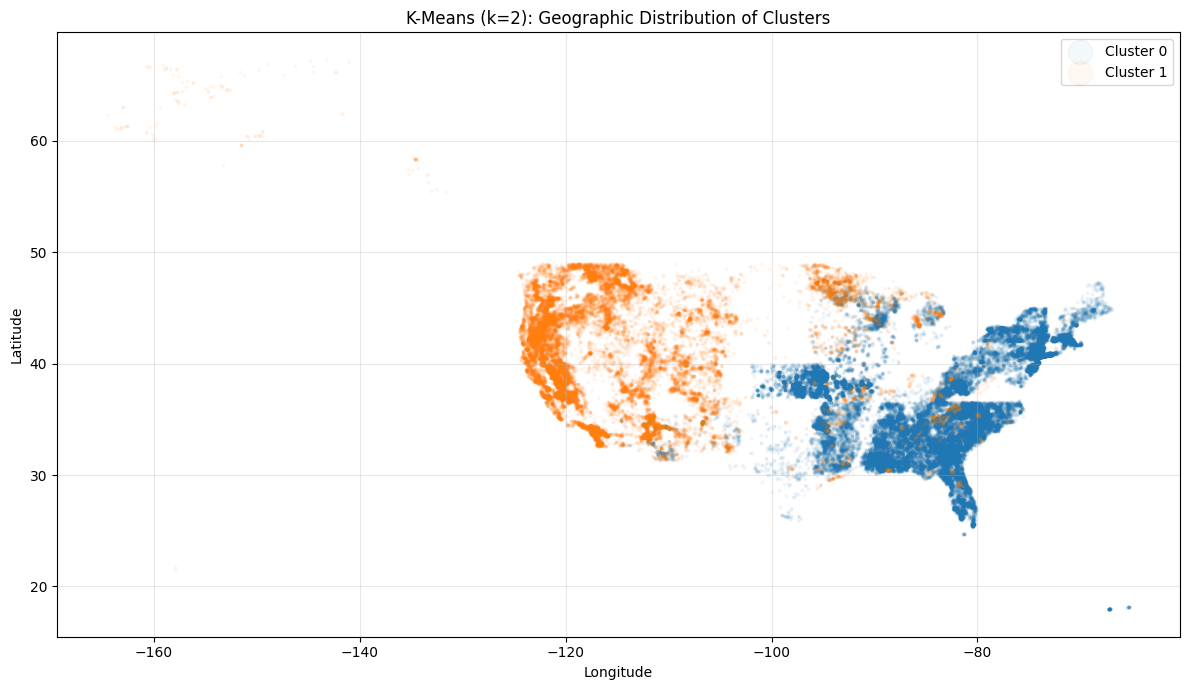

In [64]:
fig, ax = plt.subplots(figsize=(12, 7))

for cid in sorted(cluster_profile_df['cluster'].unique()):
    mask = cluster_profile_df['cluster'] == cid
    ax.scatter(cluster_profile_df.loc[mask, 'LONGITUDE'],
               cluster_profile_df.loc[mask, 'LATITUDE'],
               alpha=0.05, s=3, label=f'Cluster {cid}')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('K-Means (k=2): Geographic Distribution of Clusters')
ax.legend(markerscale=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### K-Means Results

#### Parameter Selection

The elbow plot shows a steady decline in inertia with no sharp elbow, indicating no single k value where additional clusters stop providing meaningful reduction in within-cluster variance. The silhouette score decreases gradually from k=2 (0.251) through k=3 (0.220) and k=4 (0.198), then plateaus around 0.15 from k=5 onwards. k=2 remains the clear optimum, with no competing peak at higher k values suggesting an alternative natural grouping.

A silhouette score of 0.25 indicates moderate cluster separation — the clusters are distinguishable but overlap exists, which is expected for real-world data with continuous spatial and temporal features.

MiniBatchKMeans was used instead of standard KMeans to reduce computation time on ~97,000 samples. MiniBatchKMeans processes random subsets (batch size 1024) per iteration rather than the full dataset, converging to a near-identical solution with substantially lower runtime.

#### Cluster Interpretation

K-Means with k=2 produces an east-west geographic split that corresponds to fundamentally different wildfire regimes in the United States.

**Cluster 0** (64,411 fires — 66%): Eastern and central US fires, centred at 36.3°N, 84.1°W. Dominated by New York (12.6%), North Carolina (10.6%), Georgia (9.9%), and Kansas (9.0%). Nearly all fires (99.4%) are reported through state/local agencies on predominantly private land (52.1%). The leading cause is debris burning (35.7%), followed by miscellaneous (25.5%). Fires are discovered earlier in the year (mean DOY 144, late May) and the median fire size is 1.0 acre. Discovery and containment times are later in the day (15:20 and 16:06).

**Cluster 1** (33,457 fires — 34%): Western US fires, centred at 40.9°N, 114.2°W. Dominated by California (29.2%), Oregon (15.2%), Arizona (8.2%), and Washington (7.4%). Reporting is split between state/local (45.4%) and US Forest Service (35.5%), reflecting the prevalence of federal land in the West — 30.8% of fires occur on USFS land and 10.9% on BLM land. The leading cause is lightning (34.3%). Fires are discovered later in the year (mean DOY 188, early July), consistent with western fire season peaking in summer. Median fire size is 0.1 acres.

The two clusters show a clear geographic separation (east vs west) with correlated differences in fire cause, land ownership, reporting agency, seasonality, and fire size. One possible interpretation is that these clusters reflect distinct wildfire regimes — human-caused fires on private land in the east versus lightning-caused fires on federal land in the west. However, this is an assumption based on the cluster profiles; confirming whether this corresponds to an established ecological distinction would require external domain sources.

#### Measure Selection

Mean was used for continuous features (latitude, longitude, time, DOY, year) as these are either roughly symmetric or represent central location, where the arithmetic mean is interpretable (e.g., mean latitude gives the geographic centre of the cluster). Median was used for fire size because the distribution is extremely right-skewed (mean 79.8 acres, median 0.5 acres in the full dataset), making the median a more representative measure of typical fire size within each cluster. Proportion (mean of binary columns) was used for one-hot encoded features, as the mean of a binary variable equals the fraction of observations with that attribute.

#### Geographic Visualisation

The scatter plot of latitude and longitude confirms the east-west partition visually. The boundary falls approximately along -100° longitude, roughly the 100th meridian — a well-known geographic dividing line in the US that separates the more humid east from the arid west. Overlap is visible in the central states (Minnesota, Iowa, Kansas), where both clusters contribute fires. This overlap is consistent with the moderate silhouette score of 0.25: the clusters are separable but not perfectly divided, as the transition between eastern and western fire regimes is gradual rather than discrete.

In [65]:
from sklearn.neighbors import NearestNeighbors

min_samples = 2 x 16 = 32


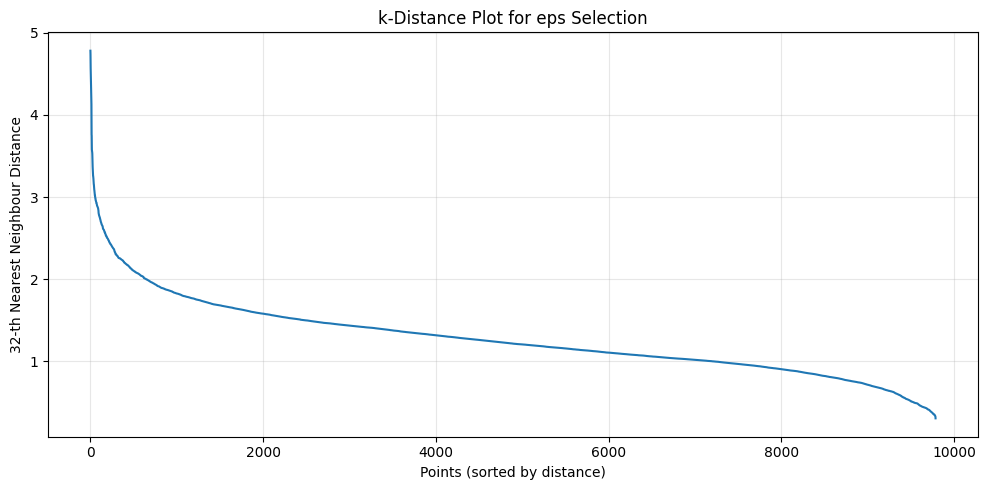

In [75]:
min_samples = 2 * X_pca.shape[1]
print(f"min_samples = 2 x {X_pca.shape[1]} = {min_samples}")

sample_size = int(len(X_pca) * 0.1)
sample_idx = np.random.RandomState(42).choice(len(X_pca), size=sample_size, replace=False)
X_sample = X_pca[sample_idx]

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_sample)
distances, _ = nn.kneighbors(X_sample)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances)
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{min_samples}-th Nearest Neighbour Distance')
ax.set_title('k-Distance Plot for eps Selection')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

In [76]:
eps_value = 2.0
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_pca)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = (labels_dbscan == -1).sum()
n_noise_pct = n_noise / len(labels_dbscan) * 100

print(f"eps={eps_value}, min_samples={min_samples}")
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise_pct:.1f}%)")
print(f"Cluster sizes: {np.bincount(labels_dbscan[labels_dbscan >= 0])}")

if n_clusters >= 2:
    non_noise = labels_dbscan >= 0
    sil_dbscan = silhouette_score(X_pca[non_noise], labels_dbscan[non_noise])
    print(f"Silhouette (excl. noise): {sil_dbscan:.4f}")

eps=2.0, min_samples=32
Clusters found: 3
Noise points: 107 (0.1%)
Cluster sizes: [97635    90    36]
Silhouette (excl. noise): 0.3496


In [79]:
original_cols = ['LATITUDE', 'LONGITUDE', 'DISCOVERY_TIME',
                 'CONT_TIME', 'DISCOVERY_DOY', 'CONT_DOY', 'FIRE_YEAR']
continuous = ['LATITUDE', 'LONGITUDE', 'DISCOVERY_TIME',
              'CONT_TIME', 'DISCOVERY_DOY', 'CONT_DOY', 'FIRE_YEAR']
skewed = ['FIRE_SIZE']
binary = [c for c in X_all.columns if c not in
          ['LATITUDE_std', 'LONGITUDE_std', 'DISCOVERY_TIME_MINUTES_std',
           'CONT_TIME_MINUTES_std', 'DISCOVERY_DOY_norm', 'CONT_DOY_norm',
           'COUNTY_freq', 'NWCG_REPORTING_UNIT_freq']]

cluster_profile_db = df.loc[X_all.index, original_cols].copy()
cluster_profile_db['FIRE_SIZE'] = df.loc[X_all.index, 'FIRE_SIZE'].values
cluster_profile_db['cluster'] = labels_dbscan

cluster_ids = sorted([c for c in cluster_profile_db['cluster'].unique() if c >= 0])

profiles_db = []
for feat in continuous:
    row = {'Feature': feat, 'Measure': 'mean'}
    for cid in cluster_ids:
        val = cluster_profile_db[cluster_profile_db['cluster'] == cid][feat].mean()
        row[f'Cluster {cid}'] = f"{val:.2f}"
    val = cluster_profile_db[cluster_profile_db['cluster'] == -1][feat].mean()
    row['Noise'] = f"{val:.2f}"
    profiles_db.append(row)

for feat in skewed:
    row = {'Feature': feat, 'Measure': 'median'}
    for cid in cluster_ids:
        val = cluster_profile_db[cluster_profile_db['cluster'] == cid][feat].median()
        row[f'Cluster {cid}'] = f"{val:.2f}"
    val = cluster_profile_db[cluster_profile_db['cluster'] == -1][feat].median()
    row['Noise'] = f"{val:.2f}"
    profiles_db.append(row)

cluster_binary_db = X_all.copy()
cluster_binary_db['cluster'] = labels_dbscan
for feat in binary:
    row = {'Feature': feat, 'Measure': 'proportion'}
    for cid in cluster_ids:
        val = cluster_binary_db[cluster_binary_db['cluster'] == cid][feat].mean()
        row[f'Cluster {cid}'] = f"{val:.1%}"
    val = cluster_binary_db[cluster_binary_db['cluster'] == -1][feat].mean()
    row['Noise'] = f"{val:.1%}"
    profiles_db.append(row)

profile_dbscan = pd.DataFrame(profiles_db).set_index('Feature')
profile_dbscan

,Measure,Cluster 0,Cluster 1,Cluster 2,Noise
Feature,,,,,
LATITUDE,mean,37.85,63.77,33.70,36.83
LONGITUDE,mean,-94.29,-155.33,-111.59,-108.12
DISCOVERY_TIME,mean,1492.19,1585.67,1451.92,1528.86
CONT_TIME,mean,1563.19,1506.11,1557.42,605.32
DISCOVERY_DOY,mean,159.29,175.52,157.94,189.82
...,...,...,...,...,...
STATE_VA,proportion,0.0%,0.0%,0.0%,0.0%
STATE_WA,proportion,2.5%,0.0%,0.0%,0.0%
STATE_WI,proportion,1.6%,0.0%,0.0%,0.0%


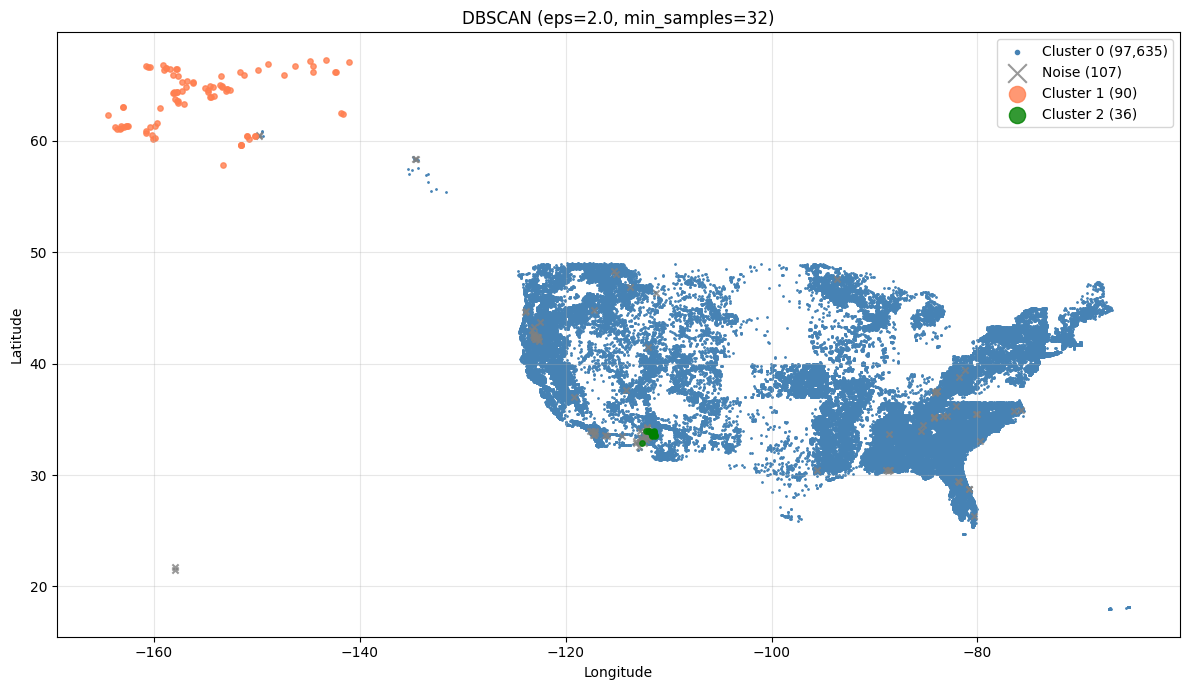

In [77]:
fig, ax = plt.subplots(figsize=(12, 7))

mask_0 = labels_dbscan == 0
locs_0 = df.loc[X_all.index[mask_0]]
ax.scatter(locs_0['LONGITUDE'], locs_0['LATITUDE'],
           alpha=1, s=1, c='steelblue', label=f'Cluster 0 ({mask_0.sum():,})')

mask_noise = labels_dbscan == -1
locs_noise = df.loc[X_all.index[mask_noise]]
ax.scatter(locs_noise['LONGITUDE'], locs_noise['LATITUDE'],
           alpha=0.8, s=20, c='grey', marker='x', label=f'Noise ({mask_noise.sum()})')

mask_1 = labels_dbscan == 1
locs_1 = df.loc[X_all.index[mask_1]]
ax.scatter(locs_1['LONGITUDE'], locs_1['LATITUDE'],
           alpha=0.8, s=15, c='coral', label=f'Cluster 1 ({mask_1.sum()})')

mask_2 = labels_dbscan == 2
locs_2 = df.loc[X_all.index[mask_2]]
ax.scatter(locs_2['LONGITUDE'], locs_2['LATITUDE'],
           alpha=0.8, s=15, c='green', label=f'Cluster 2 ({mask_2.sum()})')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'DBSCAN (eps={eps_value}, min_samples={min_samples})')
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## DBSCAN Clustering

### Parameter Selection

DBSCAN requires two parameters: `eps` (maximum distance between two points to be considered neighbours) and `min_samples` (minimum number of points to form a dense region).

`min_samples` was set to 2 × the number of dimensions (2 × 16 = 32). Sander et al. (1998) use twice the data dimensionality in their examples for higher-dimensional data, extending the original recommendation of MinPts = 4 for two-dimensional data (Ester et al., 1996).

The k-distance plot was computed on a random 10% sample of the dataset (~9,787 points) without replacement. This sample size is sufficient for a stable estimate of the k-distance distribution whilst keeping nearest-neighbour computation tractable. Sander et al. (1998) note that 1–10% of the dataset is sufficient for parameter determination via the sorted k-distance plot. The plot shows each point's distance to its 32nd nearest neighbour, sorted in descending order. The transition from steep to flat in this curve indicates where density shifts from sparse (noise) to dense (cluster), suggesting an appropriate eps value.
```

### DBSCAN Results

#### Parameter Determination

The k-distance plot shows a smooth, gradually declining curve with no sharp elbow. This is itself an informative result: a clear elbow would indicate a distinct transition from dense cluster regions to sparse noise, suggesting well-separated clusters. The absence of an elbow indicates that the data's density decreases continuously with no natural threshold where density abruptly changes. An eps value of 2.0 was selected from the region where the curve begins to flatten, consistent with the approach described by Ester et al. (1996), who recommend selecting eps at the "first valley" of the sorted k-distance graph.

#### Clustering Output

DBSCAN with eps=2.0 and min_samples=32 produces three clusters and 107 noise points (0.1%):

| | Size | % of data |
|---|---|---|
| Cluster 0 | 97,635 | 99.8% |
| Cluster 1 | 90 | 0.1% |
| Cluster 2 | 36 | 0.0% |
| Noise | 107 | 0.1% |

The silhouette score is 0.35, computed on non-noise points only — DBSCAN explicitly leaves noise unassigned, so these points have no cluster membership to evaluate. However, this silhouette value is inflated by the extreme size imbalance: 99.8% of points belong to one cluster, and the two micro-clusters are far from it in feature space, producing high separation scores that do not reflect meaningful internal structure.

#### Geographic Interpretation

The geographic plot confirms the clustering output. Cluster 0 encompasses the entire contiguous United States — DBSCAN connects all mainland fires into a single dense region through chains of nearby points in 16-dimensional PCA space. Cluster 1 (90 points) corresponds to Alaska, which is geographically and feature-wise separated from the mainland. Cluster 2 (36 points) is a small pocket in the southwest, likely a group of fires with unusual feature combinations forming a locally dense but isolated region.

The 107 noise points include locations such as Hawaii and Puerto Rico. These are not erroneous data — they are real fire records that simply do not have 32 neighbours within distance 2.0 in PCA space. Regions with very few fires in the dataset cannot meet the min_samples density threshold and are therefore left unassigned by design.

#### What DBSCAN Reveals About the Data

The dominance of a single cluster is not a failure of DBSCAN — it is a finding about the data. Wildfire records across the contiguous United States form a continuous density in feature space with no sparse gaps between regions. The only natural density-based separations are geographic extremes (Alaska) and small local anomalies. This contrasts with K-Means, which imposes a partition regardless of whether density gaps exist.

#### Geographic Interpretation

The geographic plot confirms the clustering output. Cluster 0 encompasses the entire contiguous United States — DBSCAN connects all mainland fires into a single dense region through chains of nearby points in 16-dimensional PCA space. Cluster 1 (90 points) corresponds to fires in Alaska, specifically on Fish and Wildlife Service land — 86.7% lightning-caused with a median fire size of 1,550 acres, representing a distinct regime of large, remote, lightning-ignited fires. Cluster 2 (36 points) is located in Arizona, exclusively on USFS land, dominated by campfire and miscellaneous causes with a median size of 0.10 acres.

The 107 noise points include locations such as Hawaii and Puerto Rico. These are not erroneous data — they are real fire records that simply do not have 32 neighbours within distance 2.0 in PCA space. Regions with very few fires in the dataset cannot meet the min_samples density threshold and are therefore left unassigned by design.

In [81]:
from sklearn.metrics import adjusted_rand_score

In [83]:
# K-Means labels from stored results
km2_labels = km_results['k=2']['labels']

# ARI: exclude DBSCAN noise
non_noise = labels_dbscan >= 0
ari = adjusted_rand_score(km2_labels[non_noise], labels_dbscan[non_noise])

print(f"K-Means silhouette: {km_results['k=2']['silhouette']:.4f}")
print(f"DBSCAN silhouette (excl. noise): {sil_dbscan:.4f}")
print(f"ARI (K-Means vs DBSCAN, excl. noise): {ari:.4f}")

K-Means silhouette: 0.2510
DBSCAN silhouette (excl. noise): 0.3496
ARI (K-Means vs DBSCAN, excl. noise): 0.0024


## Analysis and Comparison

### Cluster Shape and Structure

K-Means partitions the data into two convex, roughly equal groups (64,411 vs 33,457) by minimising within-cluster Euclidean distance to centroids. The resulting clusters are spherical in PCA space — K-Means cannot discover non-convex or irregularly shaped clusters by design. The two clusters correspond to an east-west geographic split with correlated differences in fire cause, land ownership, and seasonality.

DBSCAN finds clusters of arbitrary shape by connecting points through density chains. In this dataset, it identifies one dominant cluster (97,635 points) covering the contiguous US, plus two micro-clusters (Alaska and an Arizona pocket). DBSCAN does not impose any shape constraint — it follows the natural density contours of the data. The result shows that, from a density perspective, the contiguous US is one continuous region with no internal sparse gaps.

### Sensitivity to Noise and Outliers

K-Means assigns every point to a cluster, including outliers. Points in Hawaii, Alaska, and Puerto Rico are forced into whichever centroid is nearest, potentially distorting cluster centroids and inflating within-cluster variance. K-Means has no mechanism to identify or exclude anomalous records.

DBSCAN explicitly identifies noise — 107 points (0.1%) that lack sufficient local density. This includes geographically isolated locations such as Hawaii and Puerto Rico. These points do not distort any cluster because they are excluded by design. DBSCAN's noise handling is a structural advantage for datasets with geographic outliers.

### Suitability for This Dataset

K-Means is more suitable for this dataset in terms of producing interpretable, actionable clusters. The forced binary partition reveals a meaningful east-west distinction in fire regimes that aligns with differences in land ownership, fire cause, and reporting agency. The silhouette score of 0.25 indicates moderate but real separation.

DBSCAN is less suitable for producing distinct clusters because the data lacks natural density gaps — wildfire records form a continuous distribution in feature space. However, DBSCAN's result is analytically valuable: it demonstrates that the east-west split found by K-Means is a partition along the axis of greatest variance, not a separation between genuinely distinct dense regions. It also correctly isolates geographic extremes (Alaska) and identifies noise points that K-Means cannot.

### Cross-Method Agreement

The Adjusted Rand Index between K-Means and DBSCAN is 0.002, indicating near-zero agreement. This is expected: DBSCAN places 99.8% of non-noise points in a single cluster while K-Means splits them into two groups. The two algorithms find fundamentally different structures in the same data — K-Means finds the best binary partition, DBSCAN finds no partition at all. This low ARI is not evidence that either method failed; it reflects a genuine difference in what partition-based and density-based clustering measure. K-Means asks "where is the best place to cut the data in two?" while DBSCAN asks "where are there gaps in the data?" — for this dataset, these are different questions with different answers.